=============================================================================
ТРЁХФАКТОРНАЯ МЕТОДИКА ОЦЕНКИ КАЧЕСТВА АВТОМАТИЧЕСКИХ РЕФЕРАТОВ
=============================================================================

Этот notebook реализует математически обоснованную методологию оценки
качества машинных рефератов на основе статистического анализа триадных
отношений: ОТ-АР, ОТ-СР, АР-СР.

Автор: [Ваше имя]
Дата: Январь 2026

In [13]:
# =============================================================================
# ВЫБОР МЕТРИК ДЛЯ АНАЛИЗА
# =============================================================================

# Параметр выбора меры ROUGE: 'f' (F-мера), 'p' (Precision), 'r' (Recall)
ROUGE_MEASURE = 'p'  # Варианты: 'f', 'p', 'r'

ROUGE_MEASURE_NAMES = {'f': 'F-мера', 'p': 'Precision', 'r': 'Recall'}

NAMES = {'rouge1':'ROUGE-1',
         'rouge2':'ROUGE-2',
         'rougeL':'ROUGE-L',
         'bleu':'BLEU',
         'chrf':'chrF++',
         'meteor':'METEOR',
         'bertscore':'BERTScore',
         'bleurt':'BLEURT'}

LEX_MODE = 'rougeL'      # Варианты: 'rouge1', 'rouge2', 'rougeL', 'bleu', 'chrf', 'meteor'
SEM_MODE = 'bleurt'  # Варианты: 'bertscore', 'bleurt'

LEX_NAME = NAMES.get(LEX_MODE)
SEM_NAME = NAMES.get(SEM_MODE)

# -----------------------------------------------------------------------------
# ВЫБОР РЕЖИМА ПОРОГОВ
# -----------------------------------------------------------------------------
# 'centered'  - Центрированные пороги ±τσ вокруг (0,0) — рекомендуется для интерпретируемости
# 'reference' - Пороги на основе процентилей ОТ-АР — логически корректно
# 'adaptive'  - Пороги на основе процентилей машинных рефератов (исходный вариант)

MODE = 'Seq2Seq' # <--- 'Seq2Seq', 'LLMs'
S2S_SET = '17k' # <--- '480' '15k'
THRESHOLD_MODE = 'reference'  # <-- ИЗМЕНИТЕ ЗДЕСЬ: 'centered', 'reference', или 'adaptive'
CENTERED_TAU = 2.0           # Для режима 'centered': количество σ (1.5, 2.0, 2.5, 3.0)
PERCENTILE_LOW = 10          # Для режимов 'reference' и 'adaptive'
PERCENTILE_HIGH = 90         # Для режимов 'reference' и 'adaptive'

CALIBRATE_SIGMA_LIMIT = 5

In [14]:
# =============================================================================
# 1. ИМПОРТ БИБЛИОТЕК
# =============================================================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro
from typing import Dict, List, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Для корректного отображения кириллицы
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✓ Все библиотеки успешно загружены")

✓ Все библиотеки успешно загружены


In [15]:
# =============================================================================
# 2. ЗАГРУЗКА ДАННЫХ (расширенная версия)
# =============================================================================

from pathlib import Path

def load_metrics_extended(
    rouge_path: str =       f'{MODE}/data-metrics-{S2S_SET}/rouge.json',
    bleu_path: str =        f'{MODE}/data-metrics-{S2S_SET}/bleu.json',
    chrf_path: str =        f'{MODE}/data-metrics-{S2S_SET}/chrf.json',
    meteor_path: str =      f'{MODE}/data-metrics-{S2S_SET}/meteor.json',
    bertscore_path: str =   f'{MODE}/data-metrics-{S2S_SET}/bertscore.json',
    bleurt_path: str =      f'{MODE}/data-metrics-{S2S_SET}/bleurt.json',
    embeddings_path: str =  f'{MODE}/data-metrics-{S2S_SET}/embeddings.json',
    lengths_path: str =     f'{MODE}/data-metrics-{S2S_SET}/lengths.json'
) -> Dict[str, Any]:
    """
    Загружает все доступные метрики из JSON файлов.

    Parameters:
    -----------
    *_path : str
        Пути к файлам с метриками (опционально)

    Returns:
    --------
    dict : Словарь с загруженными метриками
    """
    data = {}

    # Список метрик для загрузки
    metrics_files = {
        'rouge': rouge_path,
        'bleu': bleu_path,
        'chrf': chrf_path,
        'meteor': meteor_path,
        'bertscore': bertscore_path,
        'bleurt': bleurt_path,
        'embeddings': embeddings_path,
        'lengths': lengths_path
    }

    for metric_name, file_path in metrics_files.items():
        if Path(file_path).exists():
            with open(file_path, 'r', encoding='utf-8') as f:
                data[metric_name] = json.load(f)
            print(f"  ✓ {metric_name}: загружен из {file_path}")
        else:
            print(f"  ⚠ {metric_name}: файл {file_path} не найден (пропущен)")

    return data

# Загрузка данных
print("Загрузка метрик...")
data = load_metrics_extended()

print(f"\n✓ Загружено метрик: {len(data)}")
print(f"  Доступные: {list(data.keys())}")

# Определяем количество документов и модели
if 'bertscore' in data:
    n_docs = len(data['bertscore']['ОТ-АР']['f1'])
    models = list(data['bertscore']['ОТ-СР'].keys())
elif 'rouge' in data:
    # Новый формат: rouge1 -> {p: [...], r: [...], f: [...]}
    n_docs = len(data['rouge']['ОТ-АР']['rouge1']['f'])
    models = list(data['rouge']['ОТ-СР'].keys())
else:
    raise ValueError("Не найдены базовые метрики (bertscore или rouge)")

print(f"  Документов: {n_docs}")
print(f"  Моделей: {len(models)}")
print(f"  Модели: {models}")

if 'lengths' in data:
    cr_models = [k for k in data['lengths'].get('compression_ratio', {}).keys() if k != 'АР']
    print(f"  Compression Ratio: АР + {len(cr_models)} моделей")

Загрузка метрик...
  ✓ rouge: загружен из Seq2Seq/data-metrics-17k/rouge.json
  ✓ bleu: загружен из Seq2Seq/data-metrics-17k/bleu.json
  ✓ chrf: загружен из Seq2Seq/data-metrics-17k/chrf.json
  ⚠ meteor: файл Seq2Seq/data-metrics-17k/meteor.json не найден (пропущен)
  ✓ bertscore: загружен из Seq2Seq/data-metrics-17k/bertscore.json
  ✓ bleurt: загружен из Seq2Seq/data-metrics-17k/bleurt.json
  ✓ embeddings: загружен из Seq2Seq/data-metrics-17k/embeddings.json
  ✓ lengths: загружен из Seq2Seq/data-metrics-17k/lengths.json

✓ Загружено метрик: 7
  Доступные: ['rouge', 'bleu', 'chrf', 'bertscore', 'bleurt', 'embeddings', 'lengths']
  Документов: 500
  Моделей: 6
  Модели: ['summary_TextRank', 'summary_LexRank', 'summary_mt5', 'summary_mbart', 'summary_rut5', 'summary_t5']
  Compression Ratio: АР + 6 моделей


In [16]:
# =============================================================================
# 3. ПОДГОТОВКА ДАННЫХ В ТАБЛИЧНОМ ФОРМАТЕ (расширенная версия)
# =============================================================================

# Параметр выбора меры ROUGE: 'f' (F-мера), 'p' (Precision), 'r' (Recall)
# ROUGE_MEASURE = 'f'  # Варианты: 'f', 'p', 'r'

# ROUGE_MEASURE_NAMES = {'f': 'F-мера', 'p': 'Precision', 'r': 'Recall'}

# Доступные режимы лексических метрик
LEXICAL_MODES = {
    'rouge1': ('rouge', 'rouge1'),
    'rouge2': ('rouge', 'rouge2'),
    'rougeL': ('rouge', 'rougeL'),
    'bleu': ('bleu', None),
    'chrf': ('chrf', None),
    'meteor': ('meteor', None)
}

# Доступные режимы семантических метрик
SEMANTIC_MODES = {
    'bertscore': ('bertscore', 'f1'),
    'bleurt': ('bleurt', None)
}

def prepare_dataframe_extended(
    data: Dict,
    lex_mode: str = 'rouge1',
    sem_mode: str = 'bertscore',
    rouge_measure: str = 'f'
) -> pd.DataFrame:
    """
    Преобразует загруженные метрики в pandas DataFrame.

    Parameters:
    -----------
    data : Dict
        Словарь с загруженными метриками
    lex_mode : str
        Режим лексической метрики: 'rouge1', 'rouge2', 'rougeL', 'bleu', 'chrf', 'meteor'
    sem_mode : str
        Режим семантической метрики: 'bertscore', 'bleurt'
    rouge_measure : str
        Мера ROUGE для использования: 'f', 'p', 'r'

    Returns:
    --------
    pd.DataFrame : Подготовленный датафрейм
    """
    lex_source, lex_key = LEXICAL_MODES[lex_mode]
    sem_source, sem_key = SEMANTIC_MODES[sem_mode]

    if lex_source not in data:
        raise ValueError(f"Метрика '{lex_source}' не загружена. Доступны: {list(data.keys())}")
    if sem_source not in data:
        raise ValueError(f"Метрика '{sem_source}' не загружена. Доступны: {list(data.keys())}")

    is_rouge = lex_source == 'rouge'

    # Проверяем наличие данных о компрессии
    has_compression = 'lengths' in data and 'compression_ratio' in data.get('lengths', {})

    if sem_key:
        n_docs = len(data[sem_source]['ОТ-АР'][sem_key])
    else:
        n_docs = len(data[sem_source]['ОТ-АР'])

    rows = []

    def get_lex_value(comparison_data, key, idx):
        if key is None:
            return comparison_data[idx]
        if is_rouge:
            return comparison_data[key][rouge_measure][idx]
        else:
            return comparison_data[key][idx]

    def get_sem_value(comparison_data, key, idx):
        if key is None:
            return comparison_data[idx]
        return comparison_data[key][idx]

    # 1. ОТ-АР (эталонные значения)
    for i in range(n_docs):
        lex_val = get_lex_value(data[lex_source]['ОТ-АР'], lex_key, i)
        sem_val = get_sem_value(data[sem_source]['ОТ-АР'], sem_key, i)
        cr_val = data['lengths']['compression_ratio']['АР'][i] if has_compression else None

        rows.append({
            'doc_id': i,
            'model': 'reference',
            'comparison': 'OT-AR',
            'lexical': lex_val,
            'semantic': sem_val,
            'compression_ratio': cr_val
        })

    # 2. ОТ-СР для каждой модели
    for model_name in data[sem_source]['ОТ-СР'].keys():
        for i in range(n_docs):
            lex_val = get_lex_value(data[lex_source]['ОТ-СР'][model_name], lex_key, i)
            sem_val = get_sem_value(data[sem_source]['ОТ-СР'][model_name], sem_key, i)
            cr_val = data['lengths']['compression_ratio'][model_name][i] if has_compression else None

            rows.append({
                'doc_id': i,
                'model': model_name,
                'comparison': 'OT-SR',
                'lexical': lex_val,
                'semantic': sem_val,
                'compression_ratio': cr_val
            })

    # 3. АР-СР для каждой модели
    for model_name in data[sem_source]['АР-СР'].keys():
        for i in range(n_docs):
            lex_val = get_lex_value(data[lex_source]['АР-СР'][model_name], lex_key, i)
            sem_val = get_sem_value(data[sem_source]['АР-СР'][model_name], sem_key, i)
            cr_val = data['lengths']['compression_ratio'][model_name][i] if has_compression else None

            rows.append({
                'doc_id': i,
                'model': model_name,
                'comparison': 'AR-SR',
                'lexical': lex_val,
                'semantic': sem_val,
                'compression_ratio': cr_val
            })

    df = pd.DataFrame(rows)
    return df

# =============================================================================
# ВЫБОР МЕТРИК ДЛЯ АНАЛИЗА
# =============================================================================

# NAMES = {'rouge1':'ROUGE-1',
#          'rouge2':'ROUGE-2',
#          'rougeL':'ROUGE-L',
#          'bleu':'BLEU',
#          'chrf':'chrF++',
#          'meteor':'METEOR',
#          'bertscore':'BERTScore',
#          'bleurt':'BLEURT'}

# LEX_MODE = 'chrf'      # Варианты: 'rouge1', 'rouge2', 'rougeL', 'bleu', 'chrf', 'meteor'
# SEM_MODE = 'bertscore'  # Варианты: 'bertscore', 'bleurt'

LEX_NAME = NAMES.get(LEX_MODE)
SEM_NAME = NAMES.get(SEM_MODE)

# Дополняем имя лексической метрики мерой ROUGE, если выбран ROUGE
if LEX_MODE in ('rouge1', 'rouge2', 'rougeL'):
    LEX_NAME = f"{LEX_NAME} ({ROUGE_MEASURE_NAMES[ROUGE_MEASURE]})"

print(f"\n{'='*70}")
print(f"ВЫБРАННЫЕ МЕТРИКИ:")
print(f"  Лексическая:   {LEX_NAME}")
print(f"  Семантическая: {SEM_NAME}")
if LEX_MODE in ('rouge1', 'rouge2', 'rougeL'):
    print(f"  Мера ROUGE:    {ROUGE_MEASURE_NAMES[ROUGE_MEASURE]} ({ROUGE_MEASURE})")
print(f"{'='*70}")

df_raw = prepare_dataframe_extended(data, lex_mode=LEX_MODE, sem_mode=SEM_MODE, rouge_measure=ROUGE_MEASURE)

print(f"\n✓ DataFrame создан: {df_raw.shape[0]} записей")
print(f"  Столбец compression_ratio: {'✓ присутствует' if 'compression_ratio' in df_raw.columns and df_raw['compression_ratio'].notna().any() else '✗ отсутствует'}")
print(f"\nПример данных:")
print(df_raw.head(10))
print(f"\nСтатистика:")
print(df_raw.describe())


ВЫБРАННЫЕ МЕТРИКИ:
  Лексическая:   ROUGE-L (Precision)
  Семантическая: BLEURT
  Мера ROUGE:    Precision (p)

✓ DataFrame создан: 6500 записей
  Столбец compression_ratio: ✓ присутствует

Пример данных:
   doc_id      model comparison   lexical  semantic  compression_ratio
0       0  reference      OT-AR  0.932203  0.589989           0.015526
1       1  reference      OT-AR  0.859649  0.597615           0.010290
2       2  reference      OT-AR  0.983871  0.626853           0.012481
3       3  reference      OT-AR  0.896104  0.542050           0.023041
4       4  reference      OT-AR  0.800000  0.548460           0.013394
5       5  reference      OT-AR  0.888889  0.538978           0.010099
6       6  reference      OT-AR  0.940000  0.567103           0.014359
7       7  reference      OT-AR  1.000000  0.529176           0.016089
8       8  reference      OT-AR  0.909091  0.527012           0.013424
9       9  reference      OT-AR  0.950820  0.615151           0.014974

Статистика:


✓ График 1 сохранён: tsm-reference-Seq2Seq/figures/reference_rougeL-vs-bleurt_heatmap.png


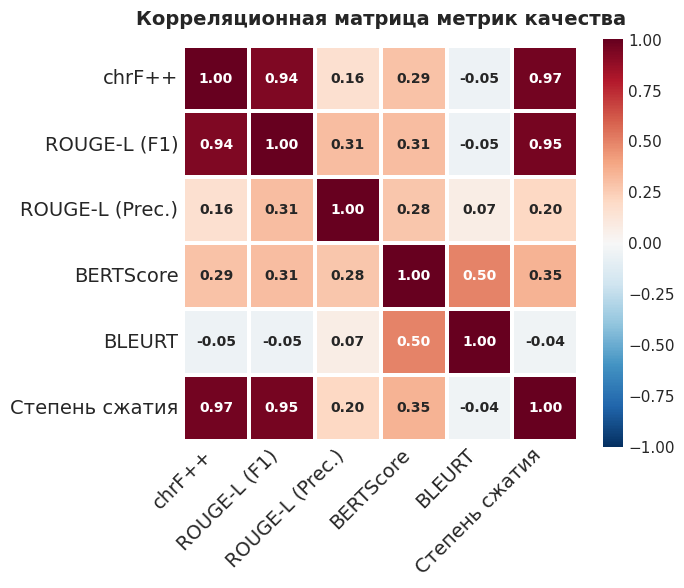

In [17]:
df_ot_ar = df_raw[df_raw['comparison'] == 'OT-AR'].copy()

for lex, lex_p, sem in zip(['chrf','rougeL','rougeL'],['f','f','p'],['bertscore','bertscore','bleurt']):
    df_cycle = prepare_dataframe_extended(data, lex_mode=lex, sem_mode=sem, rouge_measure=lex_p)
    df_ot_ar[f'lexical_{lex}_{lex_p}'] = df_cycle['lexical']
    df_ot_ar[f'semantic_{sem}'] = df_cycle['semantic']

# 8.3 Heatmap: корреляция всех метрик
has_comp_col = 'compression_ratio' in df_ot_ar.columns and df_ot_ar['compression_ratio'].notna().any()

base_cols = [
    'lexical_chrf_f', 
    'lexical_rougeL_f',  
    'lexical_rougeL_p',
    'semantic_bertscore',
    'semantic_bleurt'
    ]
# base_labels = [f'{LEX_NAME} (OS)', f'{SEM_NAME} (OS)']
base_labels = [
    f'chrF++',
    f'ROUGE-L (F1)',
    f'ROUGE-L (Prec.)',
    f'BERTScore',
    f'BLEURT'
    ]

if has_comp_col:
    base_cols.append('compression_ratio')
    base_labels.append('Степень сжатия')


metrics_for_corr = df_ot_ar[base_cols]
corr_matrix = metrics_for_corr.corr()

corr_matrix.index = base_labels
corr_matrix.columns = base_labels

fig, ax = plt.subplots(figsize=(7, 7))

# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=1.5,
            linecolor='white', cbar_kws={"shrink": 0.7},
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title('Корреляционная матрица метрик качества',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_heatmap.png', dpi=600, bbox_inches='tight', facecolor='white', pad_inches=0.5)
print(f"✓ График 1 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/figures/{THRESHOLD_MODE}_{LEX_MODE}-vs-{SEM_MODE}_heatmap.png")
plt.show()

In [18]:
# =============================================================================
# 4. КАЛИБРОВКА: ВЫЧИСЛЕНИЕ ЭТАЛОННЫХ ПАРАМЕТРОВ
# =============================================================================

def calibrate_reference_distribution(df: pd.DataFrame,
                                    tau_outlier: float = 3.0) -> Dict[str, Any]:
    """
    Этап 1: Калибровка эталонных распределений ОТ-АР.

    Процедура:
    1. Извлекаем значения ОТ-АР (близость авторских рефератов к оригиналу)
    2. Вычисляем μ и σ для каждой метрики (lexical, semantic, compression_ratio)
    3. Детектируем аномальные АР по правилу 3σ
    4. Фильтруем аномалии
    5. Пересчитываем параметры на очищенном корпусе
    """
    ot_ar = df[df['comparison'] == 'OT-AR'].copy()

    has_compression = 'compression_ratio' in ot_ar.columns and ot_ar['compression_ratio'].notna().any()

    # Шаг 1: Первичные параметры
    mu_lexical_initial = ot_ar['lexical'].mean()
    sigma_lexical_initial = ot_ar['lexical'].std(ddof=1)
    mu_semantic_initial = ot_ar['semantic'].mean()
    sigma_semantic_initial = ot_ar['semantic'].std(ddof=1)

    print("="*70)
    print("ЭТАП 1: КАЛИБРОВКА ЭТАЛОННЫХ РАСПРЕДЕЛЕНИЙ")
    print("="*70)
    print(f"\n1.1. Первичные параметры (на полном корпусе n={len(ot_ar)}):")
    print(f"     LEXICAL:      μ = {mu_lexical_initial:.4f}, σ = {sigma_lexical_initial:.4f}")
    print(f"     SEMANTIC:     μ = {mu_semantic_initial:.4f}, σ = {sigma_semantic_initial:.4f}")

    if has_compression:
        mu_comp_initial = ot_ar['compression_ratio'].mean()
        sigma_comp_initial = ot_ar['compression_ratio'].std(ddof=1)
        print(f"     COMPRESSION:  μ = {mu_comp_initial:.4f}, σ = {sigma_comp_initial:.4f}")

    # Шаг 2: Детекция аномалий (правило 3σ)
    ot_ar['z_lex'] = (ot_ar['lexical'] - mu_lexical_initial) / sigma_lexical_initial
    ot_ar['z_sem'] = (ot_ar['semantic'] - mu_semantic_initial) / sigma_semantic_initial

    outlier_condition = (np.abs(ot_ar['z_lex']) > tau_outlier) | \
                        (np.abs(ot_ar['z_sem']) > tau_outlier)

    if has_compression:
        ot_ar['z_comp'] = (ot_ar['compression_ratio'] - mu_comp_initial) / sigma_comp_initial
        outlier_condition = outlier_condition | (np.abs(ot_ar['z_comp']) > tau_outlier)

    ot_ar['is_outlier'] = outlier_condition

    outliers = ot_ar[ot_ar['is_outlier']]
    n_outliers = len(outliers)
    outlier_pct = 100 * n_outliers / len(ot_ar)

    print(f"\n1.2. Детекция аномалий (правило {tau_outlier}σ):")
    print(f"     Обнаружено аномальных АР: {n_outliers} ({outlier_pct:.1f}%)")

    if n_outliers > 0:
        print(f"\n     Статистика аномалий:")
        print(f"     - По LEXICAL:     {(np.abs(outliers['z_lex']) > tau_outlier).sum()} документов")
        print(f"     - По SEMANTIC:    {(np.abs(outliers['z_sem']) > tau_outlier).sum()} документов")
        if has_compression:
            print(f"     - По COMPRESSION: {(np.abs(outliers['z_comp']) > tau_outlier).sum()} документов")
        print(f"\n     Топ-5 аномалий по величине отклонения:")
        z_cols = ['z_lex', 'z_sem'] + (['z_comp'] if has_compression else [])
        outliers['max_z'] = outliers[z_cols].abs().max(axis=1)
        show_cols = ['doc_id', 'lexical', 'semantic'] + (['compression_ratio'] if has_compression else []) + z_cols
        top_outliers = outliers.nlargest(5, 'max_z')[show_cols]
        print(top_outliers.to_string(index=False))

    # Шаг 3: Фильтрация и пересчёт
    ot_ar_clean = ot_ar[~ot_ar['is_outlier']].copy()

    mu_lex_clean = ot_ar_clean['lexical'].mean()
    sigma_lex_clean = ot_ar_clean['lexical'].std(ddof=1)
    mu_sem_clean = ot_ar_clean['semantic'].mean()
    sigma_sem_clean = ot_ar_clean['semantic'].std(ddof=1)

    print(f"\n1.3. Параметры на очищенном корпусе (n={len(ot_ar_clean)}):")
    print(f"     LEXICAL:      μ = {mu_lex_clean:.4f}, σ = {sigma_lex_clean:.4f}")
    print(f"     SEMANTIC:     μ = {mu_sem_clean:.4f}, σ = {sigma_sem_clean:.4f}")

    result = {
        'mu_lex': mu_lex_clean,
        'sigma_lex': sigma_lex_clean,
        'mu_sem': mu_sem_clean,
        'sigma_sem': sigma_sem_clean,
        'outlier_doc_ids': outliers['doc_id'].tolist(),
        'n_clean': len(ot_ar_clean),
    }

    if has_compression:
        mu_comp_clean = ot_ar_clean['compression_ratio'].mean()
        sigma_comp_clean = ot_ar_clean['compression_ratio'].std(ddof=1)
        result['mu_comp'] = mu_comp_clean
        result['sigma_comp'] = sigma_comp_clean
        print(f"     COMPRESSION:  μ = {mu_comp_clean:.4f}, σ = {sigma_comp_clean:.4f}")

    # Тест на нормальность
    _, p_rouge = shapiro(ot_ar_clean['lexical'])
    _, p_bert = shapiro(ot_ar_clean['semantic'])

    print(f"\n1.4. Проверка нормальности (тест Шапиро-Уилка):")
    print(f"     LEXICAL:      p-value = {p_rouge:.4f} {'✓' if p_rouge > 0.05 else '✗ (не нормально)'}")
    print(f"     SEMANTIC:     p-value = {p_bert:.4f} {'✓' if p_bert > 0.05 else '✗ (не нормально)'}")

    normality = {'rouge_pval': p_rouge, 'bert_pval': p_bert}

    if has_compression:
        _, p_comp = shapiro(ot_ar_clean['compression_ratio'])
        normality['comp_pval'] = p_comp
        print(f"     COMPRESSION:  p-value = {p_comp:.4f} {'✓' if p_comp > 0.05 else '✗ (не нормально)'}")

    result['normality'] = normality

    return result

# Выполнение калибровки
calibration = calibrate_reference_distribution(df_raw)

ЭТАП 1: КАЛИБРОВКА ЭТАЛОННЫХ РАСПРЕДЕЛЕНИЙ

1.1. Первичные параметры (на полном корпусе n=500):
     LEXICAL:      μ = 0.9296, σ = 0.0592
     SEMANTIC:     μ = 0.5075, σ = 0.0950
     COMPRESSION:  μ = 0.0164, σ = 0.0086

1.2. Детекция аномалий (правило 3.0σ):
     Обнаружено аномальных АР: 22 (4.4%)

     Статистика аномалий:
     - По LEXICAL:     10 документов
     - По SEMANTIC:    7 документов
     - По COMPRESSION: 6 документов

     Топ-5 аномалий по величине отклонения:
 doc_id  lexical  semantic  compression_ratio     z_lex     z_sem    z_comp
    275 1.000000  0.227784           0.063119  1.187526 -2.945339  5.426409
     98 0.965517  0.400528           0.060484  0.605462 -1.126518  5.120482
    386 0.642857  0.291966           0.005126 -4.840996 -2.269564 -1.306058
     39 0.650000  0.204808           0.006033 -4.720426 -3.187249 -1.200831
    438 0.666667  0.499943           0.006118 -4.439095 -0.079770 -1.190961

1.3. Параметры на очищенном корпусе (n=478):
     LEXICAL: 

In [19]:
# =============================================================================
# 5. ВЫЧИСЛЕНИЕ Z-SCORES ДЛЯ ВСЕХ МОДЕЛЕЙ
# =============================================================================

def compute_z_scores(df: pd.DataFrame, calibration: Dict) -> pd.DataFrame:
    """
    Этап 2: Вычисление нормализованных отклонений (z-scores).

    Для каждого машинного реферата:
    z_lex  = (s_OS_lex  - μ_OA_lex)  / σ_OA_lex
    z_sem  = (s_OS_sem  - μ_OA_sem)  / σ_OA_sem
    z_comp = (CR_SR     - μ_OA_comp) / σ_OA_comp
    """
    # df_models = df[(df['comparison'] == 'OT-SR') & (df['model'] != 'reference')].copy()
    # df_models = df[(df['comparison'] == 'OT-SR') | (df['model'] == 'reference')].copy()
    df_models = df

    # Z-scores лексики и семантики
    df_models['z_lex'] = (df_models['lexical'] - calibration['mu_lex']) / calibration['sigma_lex']
    df_models['z_sem'] = (df_models['semantic'] - calibration['mu_sem']) / calibration['sigma_sem']

    has_compression = 'mu_comp' in calibration

    if has_compression:
        df_models['z_comp'] = (df_models['compression_ratio'] - calibration['mu_comp']) / calibration['sigma_comp']

    print("\n" + "="*70)
    print("ЭТАП 2: ВЫЧИСЛЕНИЕ Z-SCORES ДЛЯ МАШИННЫХ РЕФЕРАТОВ")
    print("="*70)
    print(f"\nОбработано {len(df_models)} машинных рефератов")
    print(f"Модели: {df_models['model'].unique().tolist()}")

    z_cols = ['z_lex', 'z_sem'] + (['z_comp'] if has_compression else [])
    print(f"\nСредние z-scores по моделям:")
    z_stats = df_models.groupby('model')[z_cols].mean()
    print(z_stats.round(3))

    if has_compression:
        print(f"\nИнтерпретация z_comp:")
        print(f"  z_comp = 0  → сжатие как у авторов (CR ≈ {calibration['mu_comp']:.3f})")
        print(f"  z_comp < 0  → сильнее сжатие (короче авторского)")
        print(f"  z_comp > 0  → слабее сжатие (длиннее авторского)")

    return df_models

df_temp = df_raw[(df_raw['comparison'] == 'OT-SR') & (df_raw['model'] != 'reference')].copy()
df_z = compute_z_scores(df_temp, calibration)

df_temp = df_raw[(df_raw['model'] == 'reference')].copy()
df_z_ref = compute_z_scores(df_temp, calibration)


ЭТАП 2: ВЫЧИСЛЕНИЕ Z-SCORES ДЛЯ МАШИННЫХ РЕФЕРАТОВ

Обработано 3000 машинных рефератов
Модели: ['summary_TextRank', 'summary_LexRank', 'summary_mt5', 'summary_mbart', 'summary_rut5', 'summary_t5']

Средние z-scores по моделям:
                   z_lex  z_sem  z_comp
model                                  
summary_LexRank    1.319 -2.928   4.160
summary_TextRank   1.320 -2.804   7.264
summary_mbart    -16.798 -3.602  -1.490
summary_mt5       -7.621 -1.579  -1.656
summary_rut5      -1.394 -1.003  -1.265
summary_t5        -3.776 -1.676  -1.574

Интерпретация z_comp:
  z_comp = 0  → сжатие как у авторов (CR ≈ 0.016)
  z_comp < 0  → сильнее сжатие (короче авторского)
  z_comp > 0  → слабее сжатие (длиннее авторского)

ЭТАП 2: ВЫЧИСЛЕНИЕ Z-SCORES ДЛЯ МАШИННЫХ РЕФЕРАТОВ

Обработано 500 машинных рефератов
Модели: ['reference']

Средние z-scores по моделям:
           z_lex  z_sem  z_comp
model                          
reference -0.085 -0.069   0.032

Интерпретация z_comp:
  z_comp = 0  → сжа

In [20]:
# =============================================================================
# 6. АДАПТИВНЫЕ ПОРОГИ И ДИАГНОСТИЧЕСКАЯ КЛАССИФИКАЦИЯ
# =============================================================================

has_compression = 'mu_comp' in calibration

def calibrate_thresholds_centered(tau: float = 2.0) -> Dict[str, float]:
    """Режим 1: Центрированные симметричные пороги ±τσ."""
    thresholds = {
        'tau_lex_upper': +tau,
        'tau_lex_lower': -tau,
        'tau_sem_upper': +tau,
        'tau_sem_lower': -tau,
        'tau_comp_upper': +tau,
        'tau_comp_lower': -tau,
        'correlation': None,
        'mode': 'centered',
        'tau_value': tau
    }

    print(f"\nРежим: ЦЕНТРИРОВАННЫЕ ПОРОГИ (±{tau}σ)")
    print(f"  LEXICAL:      [{-tau:.2f}, +{tau:.2f}]")
    print(f"  SEMANTIC:     [{-tau:.2f}, +{tau:.2f}]")
    print(f"  COMPRESSION:  [{-tau:.2f}, +{tau:.2f}]")
    print(f"  → Ожидается ~{100 - 2*(100-stats.norm.cdf(tau)*100):.1f}% данных в зоне")

    return thresholds


def calibrate_thresholds_reference(df_raw: pd.DataFrame,
                                   calibration: Dict,
                                   percentile_low: float = 10,
                                   percentile_high: float = 90) -> Dict[str, float]:
    """Режим 2: Пороги на основе процентилей АВТОРСКИХ рефератов (ОТ-АР)."""
    df_ot_ar = df_raw[df_raw['comparison'] == 'OT-AR'].copy()
    df_ot_ar = df_ot_ar[~df_ot_ar['doc_id'].isin(calibration['outlier_doc_ids'])]

    df_ot_ar['z_lex'] = (df_ot_ar['lexical'] - calibration['mu_lex']) / calibration['sigma_lex']
    df_ot_ar['z_sem'] = (df_ot_ar['semantic'] - calibration['mu_sem']) / calibration['sigma_sem']

    tau_lex_upper = np.percentile(df_ot_ar['z_lex'], percentile_high)
    tau_lex_lower = np.percentile(df_ot_ar['z_lex'], percentile_low)
    tau_sem_upper = np.percentile(df_ot_ar['z_sem'], percentile_high)
    tau_sem_lower = np.percentile(df_ot_ar['z_sem'], percentile_low)

    correlation = df_ot_ar[['z_lex', 'z_sem']].corr().iloc[0, 1]

    thresholds = {
        'tau_lex_upper': tau_lex_upper,
        'tau_lex_lower': tau_lex_lower,
        'tau_sem_upper': tau_sem_upper,
        'tau_sem_lower': tau_sem_lower,
        'correlation': correlation,
        'mode': 'reference',
        'percentile_low': percentile_low,
        'percentile_high': percentile_high
    }

    if has_compression:
        df_ot_ar['z_comp'] = (df_ot_ar['compression_ratio'] - calibration['mu_comp']) / calibration['sigma_comp']
        thresholds['tau_comp_upper'] = np.percentile(df_ot_ar['z_comp'], percentile_high)
        thresholds['tau_comp_lower'] = np.percentile(df_ot_ar['z_comp'], percentile_low)

    print(f"\nРежим: ПОРОГИ НА ОСНОВЕ АВТОРСКИХ РЕФЕРАТОВ (ОТ-АР)")
    print(f"  Процентили: {percentile_low}% / {percentile_high}%")
    print(f"  Количество АР (без выбросов): {len(df_ot_ar)}")
    print(f"  LEXICAL:      [{tau_lex_lower:.3f}, {tau_lex_upper:.3f}]")
    print(f"  SEMANTIC:     [{tau_sem_lower:.3f}, {tau_sem_upper:.3f}]")
    if has_compression:
        print(f"  COMPRESSION:  [{thresholds['tau_comp_lower']:.3f}, {thresholds['tau_comp_upper']:.3f}]")
    print(f"  → По определению ~{percentile_high - percentile_low}% авторских рефератов в зоне")

    return thresholds


def calibrate_thresholds_adaptive(df_z: pd.DataFrame,
                                  percentile_low: float = 10,
                                  percentile_high: float = 90) -> Dict[str, float]:
    """Режим 3: Пороги на основе процентилей МАШИННЫХ рефератов."""
    tau_lex_upper = np.percentile(df_z['z_lex'], percentile_high)
    tau_lex_lower = np.percentile(df_z['z_lex'], percentile_low)
    tau_sem_upper = np.percentile(df_z['z_sem'], percentile_high)
    tau_sem_lower = np.percentile(df_z['z_sem'], percentile_low)

    correlation = df_z[['z_lex', 'z_sem']].corr().iloc[0, 1]

    thresholds = {
        'tau_lex_upper': tau_lex_upper,
        'tau_lex_lower': tau_lex_lower,
        'tau_sem_upper': tau_sem_upper,
        'tau_sem_lower': tau_sem_lower,
        'correlation': correlation,
        'mode': 'adaptive',
        'percentile_low': percentile_low,
        'percentile_high': percentile_high
    }

    if has_compression and 'z_comp' in df_z.columns:
        thresholds['tau_comp_upper'] = np.percentile(df_z['z_comp'], percentile_high)
        thresholds['tau_comp_lower'] = np.percentile(df_z['z_comp'], percentile_low)

    print(f"\nРежим: АДАПТИВНЫЕ ПОРОГИ (на машинных рефератах)")
    print(f"  ⚠️  ВНИМАНИЕ: Пороги смещены относительно авторских рефератов!")
    print(f"  Процентили: {percentile_low}% / {percentile_high}%")
    print(f"  LEXICAL:      [{tau_lex_lower:.3f}, {tau_lex_upper:.3f}]")
    print(f"  SEMANTIC:     [{tau_sem_lower:.3f}, {tau_sem_upper:.3f}]")
    if 'tau_comp_upper' in thresholds:
        print(f"  COMPRESSION:  [{thresholds['tau_comp_lower']:.3f}, {thresholds['tau_comp_upper']:.3f}]")
    print(f"  Корреляция z_lex ↔ z_sem: ρ = {correlation:.3f}")

    return thresholds


def classify_summary(z_lex: float, z_sem: float, z_comp: float, thresholds: Dict[str, float]) -> Dict[str, Any]:
    """
    Классификация реферата по z-scores (трёхмерная).

    Приоритет:
    1. copying — избыток лексики
    2. under_compressed — реферат слишком длинный
    3. incomplete — провал семантики
    4. over_compressed — реферат слишком короткий
    5. low_lexical — низкая лексическая близость
    6. good — все три оси в пределах нормы
    7. ambiguous — неоднозначный паттерн
    """
    tau_L_upper = thresholds['tau_lex_upper']
    tau_L_lower = thresholds['tau_lex_lower']
    tau_S_upper = thresholds['tau_sem_upper']
    tau_S_lower = thresholds['tau_sem_lower']
    tau_C_upper = thresholds.get('tau_comp_upper', float('inf'))
    tau_C_lower = thresholds.get('tau_comp_lower', float('-inf'))

    # 2. Недостаточное сжатие: реферат слишком длинный
    if z_comp > tau_C_upper:
        conf = min((z_comp - tau_C_upper) / max(abs(tau_C_upper), 1.0), 1.0)
        return {'type': 'under_compressed', 'confidence': conf, 'description': 'Недостаточное сжатие (реферат слишком длинный)'}

    # 4. Избыточное сжатие: реферат слишком короткий
    elif z_comp < tau_C_lower:
        conf = min((tau_C_lower - z_comp) / max(abs(tau_C_lower), 1.0), 1.0)
        return {'type': 'over_compressed', 'confidence': conf, 'description': 'Избыточное сжатие (реферат слишком короткий)'}

    # 1. Копирование: избыток лексики
    elif z_lex > tau_L_upper and z_sem > tau_S_lower:
        conf = min((z_lex - tau_L_upper) / max(abs(tau_L_upper), 1.0), 1.0)
        return {'type': 'copying', 'confidence': conf, 'description': 'Избыточное копирование из оригинала'}

    # 3. Неполнота: провал семантики
    elif z_sem < tau_S_lower:
        conf = min((tau_S_lower - z_sem) / max(abs(tau_S_lower), 1.0), 1.0)
        return {'type': 'incomplete', 'confidence': conf, 'description': 'Семантическая неполнота'}

    # 5. Низкая лексика
    elif z_lex < tau_L_lower and z_sem >= tau_S_lower:
        conf = min((tau_L_lower - z_lex) / max(abs(tau_L_lower), 1.0), 1.0)
        return {'type': 'low_lexical', 'confidence': conf, 'description': 'Низкое лексическое сходство'}

    # 6. Хорошо: внутри всех трёх зон
    elif (tau_L_lower <= z_lex <= tau_L_upper) and \
         (tau_S_lower <= z_sem <= tau_S_upper) and \
         (tau_C_lower <= z_comp <= tau_C_upper):
        dist_lex = min(abs(z_lex - tau_L_upper), abs(z_lex - tau_L_lower))
        dist_sem = min(abs(z_sem - tau_S_upper), abs(z_sem - tau_S_lower))
        dist_comp = min(abs(z_comp - tau_C_upper), abs(z_comp - tau_C_lower))
        width_lex = tau_L_upper - tau_L_lower
        width_sem = tau_S_upper - tau_S_lower
        width_comp = tau_C_upper - tau_C_lower
        conf = min(
            dist_lex / (width_lex/2) if width_lex > 0 else 1.0,
            dist_sem / (width_sem/2) if width_sem > 0 else 1.0,
            dist_comp / (width_comp/2) if width_comp > 0 else 1.0
        )
        return {'type': 'good', 'confidence': conf, 'description': 'В пределах эталонного диапазона'}

    # 7. Неоднозначно
    else:
        conf = min((tau_S_upper - z_sem) / max(abs(tau_S_upper), 1.0), 1.0)
        return {'type': 'ambiguous', 'confidence': 0.0, 'description': 'Неоднозначный паттерн'}


def diagnose_all_summaries(df_z: pd.DataFrame,
                           df_raw: pd.DataFrame,
                           calibration: Dict,
                           mode: str = 'centered',
                           tau: float = 2.0,
                           percentile_low: float = 10,
                           percentile_high: float = 90) -> Tuple[pd.DataFrame, Dict]:
    """Применяет диагностическую классификацию с выбранным режимом порогов."""
    if mode == 'centered':
        thresholds = calibrate_thresholds_centered(tau)
    elif mode == 'reference':
        thresholds = calibrate_thresholds_reference(df_raw, calibration, percentile_low, percentile_high)
    elif mode == 'adaptive':
        thresholds = calibrate_thresholds_adaptive(df_z, percentile_low, percentile_high)
    else:
        raise ValueError(f"Неизвестный режим: {mode}")

    # Если z_comp отсутствует, используем 0 (нет штрафа)
    has_z_comp = 'z_comp' in df_z.columns

    diagnoses = df_z.apply(
        lambda row: classify_summary(
            row['z_lex'],
            row['z_sem'],
            row['z_comp'] if has_z_comp else 0.0,
            thresholds
        ),
        axis=1
    )

    df_z['diagnosis_type'] = diagnoses.apply(lambda x: x['type'])
    df_z['diagnosis_confidence'] = diagnoses.apply(lambda x: x['confidence'])
    df_z['diagnosis_description'] = diagnoses.apply(lambda x: x['description'])

    print(f"\n{'='*70}")
    print(f"ДИАГНОСТИЧЕСКАЯ КЛАССИФИКАЦИЯ (режим: {mode.upper()})")
    print(f"{'='*70}")

    type_counts = df_z['diagnosis_type'].value_counts()
    print(f"\nРаспределение по типам диагнозов:")
    for diag_type, count in type_counts.items():
        pct = 100 * count / len(df_z)
        print(f"  {diag_type:20s}: {count:4d} ({pct:5.1f}%)")

    print(f"\nРаспределение диагнозов по моделям (%):")
    diagnosis_by_model = pd.crosstab(df_z['model'], df_z['diagnosis_type'], normalize='index') * 100
    print(diagnosis_by_model.round(1))

    return df_z, thresholds


# =============================================================================
# ВЫПОЛНЕНИЕ КАЛИБРОВКИ ПОРОГОВ
# =============================================================================


print(f"\n{'='*70}")
print(f"ВЫБРАННЫЙ РЕЖИМ ПОРОГОВ: centered")
print(f"{'='*70}")

df_diagnosed, adaptive_thresholds = diagnose_all_summaries(
    df_z,
    df_raw,
    calibration,
    mode='centered',
    tau=CENTERED_TAU,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH
)


# THRESHOLD_MODE = 'reference'
# CENTERED_TAU = 2.0
# PERCENTILE_LOW = 10
# PERCENTILE_HIGH = 100 - PERCENTILE_LOW

print(f"\n{'='*70}")
print(f"ВЫБРАННЫЙ РЕЖИМ ПОРОГОВ: {THRESHOLD_MODE}")
print(f"{'='*70}")

df_diagnosed, adaptive_thresholds = diagnose_all_summaries(
    df_z,
    df_raw,
    calibration,
    mode=THRESHOLD_MODE,
    tau=CENTERED_TAU,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH
)
df_diagnosed_ref, adaptive_thresholds_ref = diagnose_all_summaries(
    df_z_ref,
    df_raw,
    calibration,
    mode=THRESHOLD_MODE,
    tau=CENTERED_TAU,
    percentile_low=PERCENTILE_LOW,
    percentile_high=PERCENTILE_HIGH
)

THRESHOLD_MODE_LABEL = {
    'centered': f'Центрированные (±{CENTERED_TAU}σ)',
    'reference': f'На основе АР ({PERCENTILE_LOW}-{PERCENTILE_HIGH} процентиль)',
    'adaptive': f'Адаптивные на машинных ({PERCENTILE_LOW}-{PERCENTILE_HIGH} процентиль)'
}[THRESHOLD_MODE]



ВЫБРАННЫЙ РЕЖИМ ПОРОГОВ: centered

Режим: ЦЕНТРИРОВАННЫЕ ПОРОГИ (±2.0σ)
  LEXICAL:      [-2.00, +2.00]
  SEMANTIC:     [-2.00, +2.00]
  COMPRESSION:  [-2.00, +2.00]
  → Ожидается ~95.4% данных в зоне

ДИАГНОСТИЧЕСКАЯ КЛАССИФИКАЦИЯ (режим: CENTERED)

Распределение по типам диагнозов:
  under_compressed    :  929 ( 31.0%)
  incomplete          :  838 ( 27.9%)
  low_lexical         :  611 ( 20.4%)
  good                :  458 ( 15.3%)
  over_compressed     :  164 (  5.5%)

Распределение диагнозов по моделям (%):
diagnosis_type    good  incomplete  low_lexical  over_compressed  \
model                                                              
summary_LexRank    0.8        11.8          0.0              0.0   
summary_TextRank   0.0         1.6          0.0              0.0   
summary_mbart      0.0        79.2          0.0             20.8   
summary_mt5        4.4        28.2         64.4              3.0   
summary_rut5      59.6        14.6         25.8              0.0   
summary_

In [21]:
# =============================================================================
# 7. КОМПОЗИТНАЯ МЕТРИКА КАЧЕСТВА
# =============================================================================

def compute_quality_score(df_diagnosed: pd.DataFrame,
                          df_raw: pd.DataFrame,
                          alpha: float = 0.45,
                          beta: float = 0.25,
                          gamma: float = 0.15,
                          delta: float = 0.15) -> pd.DataFrame:
    """
    Вычисление композитной метрики качества Q.

    Q = α·q_sem + β·q_lex + γ·q_align + δ·q_comp

    где:
    q_sem   = s_AS_sem × exp(-(z_OS_sem)²/2)
    q_lex   = s_AS_lex × exp(-(z_OS_lex)²/2)
    q_comp  = exp(-(z_OS_comp)²/2)
    q_align = exp(-(z_OS_lex - z_OS_sem)²/2)

    Компоненты:
    - q_sem, q_lex: прямое сходство с АР, штрафованное за отклонение от эталона
    - q_align: штраф за дисбаланс между лексической и семантической близостью
    - q_comp: штраф за отклонение степени сжатия от авторского эталона
    """
    df_ar_sr = df_raw[(df_raw['comparison'] == 'AR-SR') | (df_raw['comparison'] == 'OT-AR')].copy()

    df_merged = df_diagnosed.merge(
        df_ar_sr[['doc_id', 'model', 'lexical', 'semantic']],
        on=['doc_id', 'model'],
        suffixes=('_os', '_as')
    )

    # Компоненты качества
    df_merged['q_sem'] = df_merged['semantic_as'] * np.exp(-df_merged['z_sem']**2 / 2)
    df_merged['q_lex'] = df_merged['lexical_as'] * np.exp(-df_merged['z_lex']**2 / 2)
    df_merged['q_align'] = np.exp(-(df_merged['z_lex'] - df_merged['z_sem'])**2 / 2)

    has_z_comp = 'z_comp' in df_merged.columns

    if has_z_comp:
        df_merged['q_comp'] = np.exp(-df_merged['z_comp']**2 / 2)
        df_merged['Q'] = (alpha * df_merged['q_sem'] +
                          beta * df_merged['q_lex'] +
                          gamma * df_merged['q_align'] +
                          delta * df_merged['q_comp'])
        weight_str = f"α={alpha} (семантика), β={beta} (лексика), γ={gamma} (выравнивание), δ={delta} (компрессия)"
    else:
        df_merged['Q'] = alpha * df_merged['q_sem'] + beta * df_merged['q_lex'] + gamma * df_merged['q_align']
        weight_str = f"α={alpha} (семантика), β={beta} (лексика), γ={gamma} (выравнивание)"

    print("\n" + "="*70)
    print("ЭТАП 4: КОМПОЗИТНАЯ МЕТРИКА КАЧЕСТВА")
    print("="*70)
    print(f"\nВеса: {weight_str}")

    print(f"\nСредние значения Q по моделям:")
    q_by_model = df_merged.groupby('model')['Q'].agg(['mean', 'std', 'min', 'max'])
    print(q_by_model.round(4))

    print(f"\n🏆 Рейтинг моделей по Q:")
    ranking = df_merged.groupby('model')['Q'].mean().sort_values(ascending=False)
    for rank, (model, q_score) in enumerate(ranking.items(), 1):
        print(f"   {rank}. {model:20s}: Q = {q_score:.4f}")

    return df_merged

df_final = compute_quality_score(df_diagnosed, df_raw, alpha=0.45, beta=0.25, gamma=0.15, delta=0.15)
df_final_ref = compute_quality_score(df_diagnosed_ref, df_raw, alpha=0.45, beta=0.25, gamma=0.15, delta=0.15)

ADAPTIVE_THRESHOLDS = adaptive_thresholds


ЭТАП 4: КОМПОЗИТНАЯ МЕТРИКА КАЧЕСТВА

Веса: α=0.45 (семантика), β=0.25 (лексика), γ=0.15 (выравнивание), δ=0.15 (компрессия)

Средние значения Q по моделям:
                    mean     std     min     max
model                                           
summary_LexRank   0.0399  0.0476 -0.0000  0.2751
summary_TextRank  0.0288  0.0418  0.0000  0.2911
summary_mbart     0.0549  0.0339  0.0064  0.1502
summary_mt5       0.1111  0.0756  0.0224  0.4881
summary_rut5      0.3388  0.1474  0.0386  0.7445
summary_t5        0.1799  0.1368  0.0148  0.6341

🏆 Рейтинг моделей по Q:
   1. summary_rut5        : Q = 0.3388
   2. summary_t5          : Q = 0.1799
   3. summary_mt5         : Q = 0.1111
   4. summary_mbart       : Q = 0.0549
   5. summary_LexRank     : Q = 0.0399
   6. summary_TextRank    : Q = 0.0288

ЭТАП 4: КОМПОЗИТНАЯ МЕТРИКА КАЧЕСТВА

Веса: α=0.45 (семантика), β=0.25 (лексика), γ=0.15 (выравнивание), δ=0.15 (компрессия)

Средние значения Q по моделям:
             mean     std     min

In [22]:
# =============================================================================
# 8. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print("\n" + "="*70)
print("ЭТАП 5: ВИЗУАЛИЗАЦИЯ")
print("="*70)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Цветовая палитра для типов диагнозов (расширенная)
DIAGNOSIS_COLORS = {
    # 'good': '#2ecc71',            # зеленый — хорошие рефераты
    # 'copying': '#e74c3c',         # красный — копирование
    # 'incomplete': '#9b59b6',      # фиолетовый — неполнота
    # 'low_lexical': '#3498db',     # синий — низкая лексика
    # 'over_compressed': '#e67e22', # оранжевый — слишком короткий
    # 'under_compressed': '#f1c40f',# жёлтый — слишком длинный
    # 'ambiguous': '#95a5a6'        # серый — неоднозначные
    'good': '#2ecc71',       # зеленый - хорошие рефераты
    'copying': '#3498db',    # красный - копирование
    'incomplete': '#9b59b6', # фиолетовый - неполнота
    'low_lexical': '#f39c12',# #3cd7e7 оранжевый - низкая лексика (новая категория)
    'ambiguous': '#95a5a6',  # серый - неоднозначные

    'under_compressed': '#e74c3c',
    'over_compressed': '#008f8f' # #f39c12 #e67e22
}

DIAGNOSIS_ZONES = [
    'Целевая зона',
    'Избыточное копирование',
    'Семантическая неполнота',
    'Низкая лекс. сходство',
    'Неоднозначный паттерн',
    'Недостаточное сжатие',
    'Избыточное сжатие',
]

# Цветовая палитра для моделей
MODEL_COLORS = {
    'reference':'#f1c40f',

    'summary_lingvo': '#2ecc71',
    'summary_TextRank': '#3498db',
    'summary_LexRank': '#e74c3c',
    'summary_mt5': '#9b59b6',
    'summary_mbart': '#f39c12',
    'summary_rut5': '#1abc9c',
    'summary_t5': '#e67e22',

    'summary_forzer_GigaChat3-10B-A1.8B_latest':'#2ecc71',
    'summary_qwen2.5_7b':'#3498db',
    'summary_qwen3_8b':'#9b59b6',
    'summary_yandex_YandexGPT-5-Lite-8B-instruct-GGUF_latest':'#e74c3c',
}

MODEL_COLORS_2 = {
    'summary_lingvo': 'blue',
    'summary_TextRank': 'orange',
    'summary_LexRank': 'green',
    'summary_mt5': 'red',
    'summary_mbart': 'purple',
    'summary_rut5': 'brown',
    'summary_t5': 'pink',

    'summary_forzer_GigaChat3-10B-A1.8B_latest':'#2ecc71',
    'summary_qwen2.5_7b':'#3498db',
    'summary_qwen3_8b':'#9b59b6',
    'summary_yandex_YandexGPT-5-Lite-8B-instruct-GGUF_latest':'#e74c3c',
}

# ------
#  LLMs
# ------
SHORT_LABELS = [
    'GigaChat3',
    'Qwen2.5',
    'Qwen3',
    'YandexGPT-5'
]

INTER_LABELS = {
    'reference':'Авторский реферат',
    'summary_forzer_GigaChat3-10B-A1.8B_latest':'GigaChat3', 
    'summary_qwen2.5_7b':'Qwen2.5', 
    'summary_qwen3_8b':'Qwen3', 
    'summary_yandex_YandexGPT-5-Lite-8B-instruct-GGUF_latest':'YandexGPT-5',
}


ЭТАП 5: ВИЗУАЛИЗАЦИЯ


✓ График 1 сохранён: tsm-reference-Seq2Seq/figures/rougeL-vs-bleurt_diagnostic_scatter.png


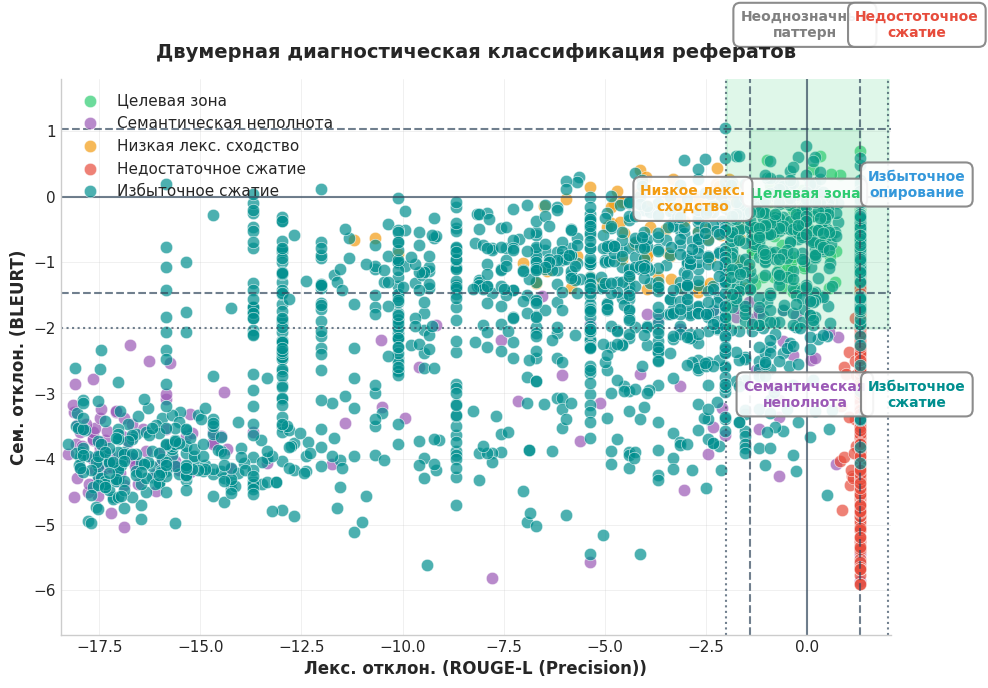

In [23]:
# 8.0 Scatter plot: z_lex vs z_sem с зонами диагностики
fig, ax = plt.subplots(figsize=(10, 7))

# Отрисовка точек по типам диагнозов
for i, (diag_type, color) in enumerate(DIAGNOSIS_COLORS.items()):
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        ax.scatter(subset['z_lex'], subset['z_sem'], 
                   c=color, 
                #    label=diag_type.capitalize(), 
                   label=DIAGNOSIS_ZONES[i],
                   alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
        
# for model, color in MODEL_COLORS_2.items():
#     subset = df_final[df_final['model'] == model]
#     if len(subset) > 0:
#         ax.scatter(subset['z_lex'], subset['z_sem'], 
#                   c=color, label=model.capitalize(), 
#                   alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

# Оси
ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(x=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.7)

# Границы зон (τ = 2)
# tau = 2.0
tau_lex_upper = adaptive_thresholds.get('tau_lex_upper')
tau_lex_lower = adaptive_thresholds.get('tau_lex_lower')
tau_sem_upper = adaptive_thresholds.get('tau_sem_upper')
tau_sem_lower = adaptive_thresholds.get('tau_sem_lower')

ax.axhline(y=tau_sem_lower, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=tau_sem_upper, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=tau_lex_lower, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=tau_lex_upper, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.7)

# Прямоугольник "хорошей зоны"
from matplotlib.patches import Rectangle
good_zone = Rectangle((tau_lex_lower, tau_sem_lower), tau_lex_upper-tau_lex_lower, tau_sem_upper-tau_sem_lower, 
                      linewidth=2, edgecolor='#2ecc71', 
                      facecolor='#2ecc71', alpha=0.1)
ax.add_patch(good_zone)

ax.axhline(y=2, color='#34495e', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(y=-2, color='#34495e', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(x=2, color='#34495e', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(x=-2, color='#34495e', linestyle=':', linewidth=1.5, alpha=0.7)

# Прямоугольник "хорошей зоны" τ = 2
from matplotlib.patches import Rectangle
good_zone = Rectangle((-2, -2), 4, 4, 
                      linewidth=2, edgecolor='#2ecc71', 
                      facecolor='#2ecc71', alpha=0.15)
ax.add_patch(good_zone)

# Аннотации зон с улучшенным стилем
bbox_style = dict(boxstyle='round,pad=0.5', facecolor='white', 
                  edgecolor='gray', alpha=0.9, linewidth=1.5)

# Центр целевой зоны
center_x = (tau_lex_lower + tau_lex_upper) / 2
center_y = (tau_sem_lower + tau_sem_upper) / 2

# Аннотации зон с улучшенным стилем
ax.text(center_x, 0, 'Целевая зона', ha='center', fontsize=10, 
        fontweight='bold', bbox=bbox_style, color='#2ecc71')
ax.text(tau_lex_upper + 1.4, 0, 'Избыточное\nопирование', ha='center', fontsize=10,# rotation=90,
        fontweight='bold', bbox=bbox_style, color='#3498db')

ax.text(center_x, -3.2, 'Семантическая\nнеполнота', ha='center', fontsize=10,
        fontweight='bold', bbox=bbox_style, color='#9b59b6')
ax.text(center_x, tau_sem_upper + 1.4, 'Неоднозначный\nпаттерн', ha='center', fontsize=10,
        fontweight='bold', bbox=bbox_style, color='gray')
if 'low_lexical' in list(df_final['diagnosis_type']):
    ax.text(tau_lex_lower - 1.4, center_y, 'Низкое лекс.\nсходство', ha='center', fontsize=10,# rotation=90,
            fontweight='bold', bbox=bbox_style, color='#f39c12') # #f1c40f #3498db


if 'under_compressed' in list(df_final['diagnosis_type']):
    ax.text(tau_lex_upper + 1.4, tau_sem_upper + 1.4, 'Недостоточное\nсжатие', ha='center', fontsize=10,# rotation=90,
            fontweight='bold', bbox=bbox_style, color='#e74c3c')
if 'over_compressed' in list(df_final['diagnosis_type']):
    ax.text(tau_lex_upper + 1.4, -3.2, 'Избыточное\nсжатие', ha='center', fontsize=10,# rotation=90,
            fontweight='bold', bbox=bbox_style, color='#008f8f')


ax.set_xlabel(f'Лекс. отклон. ({LEX_NAME})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Сем. отклон. ({SEM_NAME})', fontsize=12, fontweight='bold')
ax.set_title('Двумерная диагностическая классификация рефератов', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=11, framealpha=0.95, 
          edgecolor='gray', fancybox=True, shadow=True)
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)

margin = 0.75
x_min, x_max = min(df_final['z_lex']), max(df_final['z_lex'])
y_min, y_max = min(df_final['z_sem']), max(df_final['z_sem'])
ax.set_xlim(x_min-margin+1, x_max+margin)
ax.set_ylim(y_min-margin, y_max+margin)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_diagnostic_scatter.png', dpi=600, bbox_inches='tight', facecolor='white')
print(f"✓ График 1 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/figures/{LEX_MODE}-vs-{SEM_MODE}_diagnostic_scatter.png")
plt.show()

✓ График 1 сохранён: tsm-reference-Seq2Seq/figures/rougeL-vs-bleurt_diagnostic_scatter_3d.png


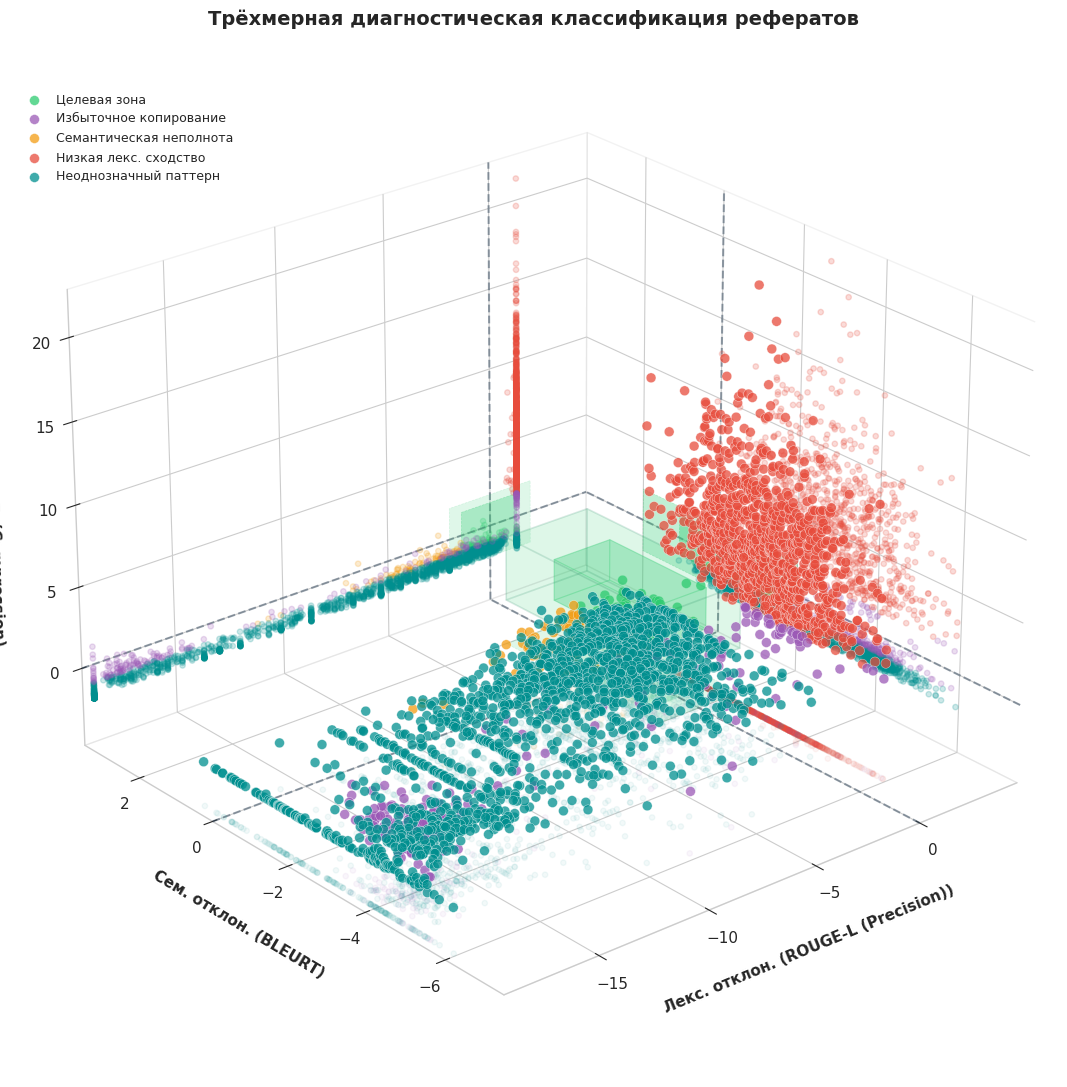

In [24]:
# 8.1 3D Scatter plot: z_lex vs z_sem vs z_comp с проекциями на плоскости
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(111, projection='3d')

# Пороги
tau_lex_upper = adaptive_thresholds.get('tau_lex_upper')
tau_lex_lower = adaptive_thresholds.get('tau_lex_lower')
tau_sem_upper = adaptive_thresholds.get('tau_sem_upper')
tau_sem_lower = adaptive_thresholds.get('tau_sem_lower')
tau_comp_upper = adaptive_thresholds.get('tau_comp_upper', 2.0)
tau_comp_lower = adaptive_thresholds.get('tau_comp_lower', -2.0)

# Пределы осей (с запасом)
margin = 1.5
x_lo = min(df_final['z_lex'].min(), tau_lex_lower) - margin + 1.0
x_hi = max(df_final['z_lex'].max(), tau_lex_upper) + margin + 2.0
y_lo = min(df_final['z_sem'].min(), tau_sem_lower) - margin
y_hi = max(df_final['z_sem'].max(), tau_sem_upper) + margin + 1.0
z_lo = min(df_final['z_comp'].min(), tau_comp_lower) - margin - 1.2
z_hi = max(df_final['z_comp'].max(), tau_comp_upper) + margin

# --- 1. Проекции на стенки (рисуем первыми, чтобы были на заднем плане) ---
proj_alpha = 0.20
proj_size = 15

for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        zl = subset['z_lex'].values
        zs = subset['z_sem'].values
        zc = subset['z_comp'].values

        # Проекция на плоскость XY (z = z_lo) — «пол»
        ax.scatter(zl, zs, np.full_like(zl, z_lo), c=color,
                   alpha=0.05, s=proj_size) # , marker='o', edgecolors='none'

        # Проекция на плоскость XZ (y = y_hi) — «задняя стена»
        ax.scatter(zl, np.full_like(zs, y_hi), zc, c=color,
        # ax.scatter(zl[::-1], np.full_like(zs[::-1], y_hi), zc[::-1], c=color,
                   alpha=proj_alpha, s=proj_size)

        # Проекция на плоскость YZ (x = x_lo) — «левая стена»
        ax.scatter(np.full_like(zl, x_hi), zs, zc, c=color,
                   alpha=proj_alpha, s=proj_size)
        
# --- Оси ---
x_coords = np.array([x_lo, x_hi])
y_coords = np.array([y_hi, y_hi])
z_coords = np.array([0, 0])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)
x_coords = np.array([x_hi, x_hi])
y_coords = np.array([y_lo, y_hi])
z_coords = np.array([0, 0])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)
x_coords = np.array([x_lo, x_hi])
y_coords = np.array([0, 0])
z_coords = np.array([z_lo, z_lo])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)

x_coords = np.array([0, 0])
y_coords = np.array([y_hi, y_hi])
z_coords = np.array([z_lo, z_hi])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)
x_coords = np.array([x_hi, x_hi])
y_coords = np.array([0, 0])
z_coords = np.array([z_lo, z_hi])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)
x_coords = np.array([0, 0])
y_coords = np.array([y_lo, y_hi])
z_coords = np.array([z_lo, z_lo])
ax.plot(x_coords, y_coords, z_coords, color='#34495e', linestyle='--', linewidth=1.5, alpha=0.5)

labels = [
    # 'Целевая зона',
    # 'Копирование',
    # 'Неполнота',
    # 'Низкая лексика',
    # 'Избыточность',
    # 'Недостаточное сжатие',
    
    'Целевая зона',
    'Избыточное копирование',
    'Семантическая неполнота',
    'Низкая лекс. сходство',
    'Неоднозначный паттерн',
    'Недостаточное сжатие',
    'Избыточное сжатие',
    ]
# --- 2. Основные точки (поверх проекций) ---
i = 0
for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        ax.scatter(subset['z_lex'], subset['z_sem'], subset['z_comp'],
                   c=color, label=labels[i], # diag_type.replace('_', ' ').capitalize(),
                   alpha=0.75, s=50, edgecolors='white', linewidth=0.3, depthshade=True)
        i+=1

# --- 3. Целевая зона: полупрозрачный параллелепипед ---
x0, x1 = tau_lex_lower, tau_lex_upper
y0, y1 = tau_sem_lower, tau_sem_upper
z0, z1 = tau_comp_lower, tau_comp_upper

faces = [
    [[x0,y0,z0],[x1,y0,z0],[x1,y1,z0],[x0,y1,z0]],
    [[x0,y0,z1],[x1,y0,z1],[x1,y1,z1],[x0,y1,z1]],
    [[x0,y0,z0],[x1,y0,z0],[x1,y0,z1],[x0,y0,z1]],
    [[x0,y1,z0],[x1,y1,z0],[x1,y1,z1],[x0,y1,z1]],
    [[x0,y0,z0],[x0,y1,z0],[x0,y1,z1],[x0,y0,z1]],
    [[x1,y0,z0],[x1,y1,z0],[x1,y1,z1],[x1,y0,z1]],
]
poly = Poly3DCollection(faces, alpha=0.18, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.8)
ax.add_collection3d(poly)
faces = [
    [[-2,-2,-2],[2,-2,-2],[2,2,-2],[-2,2,-2]],
    [[-2,-2,2],[2,-2,2],[2,2,2],[-2,2,2]],
    [[-2,-2,-2],[2,-2,-2],[2,-2,2],[-2,-2,2]],
    [[-2,2,-2],[2,2,-2],[2,2,2],[-2,2,2]],
    [[-2,-2,-2],[-2,2,-2],[-2,2,2],[-2,-2,2]],
    [[2,-2,-2],[2,2,-2],[2,2,2],[2,-2,2]],
]
poly = Poly3DCollection(faces, alpha=0.08, facecolor='#2ecc71', edgecolor='#00754a', linewidth=1.2)
ax.add_collection3d(poly)


# --- 4.1 Проекции целевой зоны на стенки (прямоугольники-тени) ---
# На пол (XY, z=z_lo)
floor_rect = [[x0,y0,z_lo],[x1,y0,z_lo],[x1,y1,z_lo],[x0,y1,z_lo]]
poly_floor = Poly3DCollection([floor_rect], alpha=0.15, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_floor)
floor_rect = [[-2,-2,z_lo],[2,-2,z_lo],[2,2,z_lo],[-2,2,z_lo]]
poly_floor = Poly3DCollection([floor_rect], alpha=0.15, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_floor)

# На заднюю стену (XZ, y=y_hi)
back_rect = [[x0,y_hi,z0],[x1,y_hi,z0],[x1,y_hi,z1],[x0,y_hi,z1]]
poly_back = Poly3DCollection([back_rect], alpha=0.3, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_back)
back_rect = [[-2,y_hi,-2],[2,y_hi,-2],[2,y_hi,2],[-2,y_hi,2]]
poly_back = Poly3DCollection([back_rect], alpha=0.15, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_back)

# На левую стену (YZ, x=x_lo)
left_rect = [[x_hi,y0,z0],[x_hi,y1,z0],[x_hi,y1,z1],[x_hi,y0,z1]]
poly_left = Poly3DCollection([left_rect], alpha=0.4, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_left)
left_rect = [[x_hi,-2,-2],[x_hi,2,-2],[x_hi,2,2],[x_hi,-2,2]]
poly_left = Poly3DCollection([left_rect], alpha=0.3, facecolor='#2ecc71', edgecolor='#2ecc71', linewidth=0.5, linestyle='--')
ax.add_collection3d(poly_left)


# --- 5. Оформление ---
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_zlim(z_lo, z_hi)

ax.set_xlabel(f'\nЛекс. отклон. ({LEX_NAME})', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel(f'\nСем. отклон. ({SEM_NAME})', fontsize=11, fontweight='bold', labelpad=10)
ax.set_zlabel('\nОтклон. сжат. (Compression)', fontsize=11, fontweight='bold', labelpad=10)

ax.set_title(f'Трёхмерная диагностическая классификация рефератов', # \nПороги: {THRESHOLD_MODE_LABEL}
             fontsize=14, fontweight='bold', pad=-20)

ax.legend(loc='upper left', fontsize=9, framealpha=0.95,
          edgecolor='gray', fancybox=True, shadow=True,
          bbox_to_anchor=(0.0, 0.95))

# Угол обзора
ax.view_init(elev=90-65, azim=-90-40, roll=0)

# Панели
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
ax.xaxis.pane.set_alpha(0.1)
ax.yaxis.pane.set_alpha(0.1)
ax.zaxis.pane.set_alpha(0.1)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_diagnostic_scatter_3d.png', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.5)
print(f"✓ График 1 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/figures/{LEX_MODE}-vs-{SEM_MODE}_diagnostic_scatter_3d.png")
plt.show()

In [26]:
# 8.1 Scatter plots: z_rouge vs z_bert - ОТДЕЛЬНО ДЛЯ КАЖДОЙ МОДЕЛИ

DIAG_TRANSLATE = {
    'good': 'Целевая зона',
    'copying': 'Избыточное копирование',
    'incomplete': 'Семантическая неполнота',
    'low_lexical': 'Лексическая неполнота',
    'ambiguous': 'Неоднозначный паттерн',

    'under_compressed': 'Недостаточное сжатие',
    'over_compressed': 'Избыточное сжатие'
}

def plot_model_diagnostic(df_model, model_name, thresholds):
    """
    Создаёт диагностический scatter plot для одной модели с АДАПТИВНЫМИ порогами.
    """
    from matplotlib.patches import Rectangle
    
#     fig, ax = plt.subplots(figsize=(10, 9))
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Извлекаем адаптивные пороги
    # tau_lex_upper = thresholds['tau_lex_upper']
    # tau_lex_lower = thresholds['tau_lex_lower']
    # tau_sem_upper = thresholds['tau_sem_upper']
    # tau_sem_lower = thresholds['tau_sem_lower']

    tau_lex_upper = adaptive_thresholds.get('tau_lex_upper')
    tau_lex_lower = adaptive_thresholds.get('tau_lex_lower')
    tau_sem_upper = adaptive_thresholds.get('tau_sem_upper')
    tau_sem_lower = adaptive_thresholds.get('tau_sem_lower')
    
    # Отрисовка точек по типам диагнозов
    for diag_type, color in DIAGNOSIS_COLORS.items():
        subset = df_model[df_model['diagnosis_type'] == diag_type]
        if len(subset) > 0:
            ax.scatter(subset['z_lex'], subset['z_sem'], 
                      c=color, label=DIAG_TRANSLATE.get(diag_type), #diag_type.capitalize().replace('_', ' '), 
                      alpha=0.8, s=100, edgecolors='white', linewidth=1)
    
    # АДАПТИВНЫЕ границы зон (не симметричные!)
    ax.axvline(x=tau_lex_upper, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.7,)
            #    label=f'τ_{LEX_MODE}+ = {tau_lex_upper:.2f}')
    ax.axvline(x=tau_lex_lower, color='#3498db', linestyle='--', linewidth=2, alpha=0.7,)
            #    label=f'τ_{LEX_MODE}+ = {tau_lex_lower:.2f}')
    
    ax.axhline(y=tau_sem_upper, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.7,)
            #    label=f'τ_{SEM_MODE}+ = {tau_sem_upper:.2f}')
    ax.axhline(y=tau_sem_lower, color='#3498db', linestyle='--', linewidth=2, alpha=0.7, )
            #    label=f'τ_{SEM_MODE}- = {tau_sem_lower:.2f}')

    ax.axhline(y=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)
    ax.axvline(x=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)
    
    # АДАПТИВНЫЙ прямоугольник "хорошей зоны" (не квадрат!)
    width_good = tau_lex_upper - tau_lex_lower
    height_good = tau_sem_upper - tau_sem_lower
    good_zone = Rectangle((tau_lex_lower, tau_sem_lower), width_good, height_good, 
                          linewidth=2.5, edgecolor='#2ecc71', 
                          facecolor='#2ecc71', alpha=0.15)
    ax.add_patch(good_zone)
    
    # Аннотации зон
    bbox_style = dict(boxstyle='round,pad=0.5', facecolor='white', 
                      edgecolor='gray', alpha=0.9, linewidth=1.5)
    
    # Центр целевой зоны
    center_x = (tau_lex_lower + tau_lex_upper) / 2
    center_y = (tau_sem_lower + tau_sem_upper) / 2
    
    # ax.text(center_x, tau_sem_upper + 0.3, 'Целевая зона', ha='center', fontsize=11, 
    #         fontweight='bold', bbox=bbox_style, color='#2ecc71')
    # ax.text(tau_lex_upper + 0.4, center_y, 'Копирование', ha='center', fontsize=10, rotation=90,
    #         fontweight='bold', bbox=bbox_style, color='#e74c3c')
    # ax.text(center_x, tau_sem_lower - 0.3, 'Неполнота', ha='center', fontsize=10,
    #         fontweight='bold', bbox=bbox_style, color='#9b59b6')
    
    # ax.text(center_x, tau_sem_upper - 0.4, 'Целевая зона', ha='center', fontsize=11, 
    #     fontweight='bold', bbox=bbox_style, color='#2ecc71')

    # ax.text(tau_lex_upper + 0.4, center_y - 0.4, 'Копирование', ha='center', fontsize=10, rotation=90,
    #         fontweight='bold', bbox=bbox_style, color='#e74c3c')
    
    # if 'low_lexical' in list(df_final['diagnosis_type']):
    #     ax.text(tau_lex_lower - 0.4, center_y - 0.4, 'Низкая лексика', ha='center', fontsize=10, rotation=90,
    #             fontweight='bold', bbox=bbox_style, color='#f39c12')

    # ax.text(center_x, tau_sem_lower - 0.4, 'Неполнота', ha='center', fontsize=10,
    #         fontweight='bold', bbox=bbox_style, color='#9b59b6')
    # ax.text(center_x, tau_sem_upper + 0.4, 'Избыточность', ha='center', fontsize=10,
    #         fontweight='bold', bbox=bbox_style, color='gray')

    # Статистика по модели
    stats_text_pct = f"n = {len(df_model)}, пороги: ±τ\n"
    for diag_type in DIAGNOSIS_COLORS.keys():
        count = (df_model['diagnosis_type'] == diag_type).sum()
        pct = 100 * count / len(df_model) if len(df_model) > 0 else 0
        if count > 0:
            # stats_text_pct += f"{diag_type.capitalize().replace('_', ' ')}: {count} ({pct:.1f}%)\n"
            stats_text_pct += f"{DIAG_TRANSLATE.get(diag_type)}: {count} ({pct:.1f}%)\n"

    stats_text_tau = f"n = {len(df_model)}, пороги: ±τ\n"
    for diag_type in DIAGNOSIS_COLORS.keys():
        count = (df_model['diagnosis_type'] == diag_type).sum()
        pct = 100 * count / len(df_model) if len(df_model) > 0 else 0
        if count > 0:
            stats_text_tau += f"{DIAG_TRANSLATE.get(diag_type)}: {count} ({pct:.1f}%)\n"
    
    ax.text(0.02, 0.98, stats_text_pct, transform=ax.transAxes, 
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.text(0.02, 0.98, stats_text_tau, transform=ax.transAxes, 
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel(f'Z-score ({LEX_NAME})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Z-score ({SEM_NAME})', fontsize=12, fontweight='bold')
    
    # Красивое название модели
    model_display_name = model_name.replace('summary_', '').upper()
    ax.set_title(f'Диагностика модели: {INTER_LABELS.get(model_name)}', 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(loc='upper right', fontsize=9, framealpha=0.95, 
              edgecolor='gray', fancybox=True, shadow=True)
    ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
    
    # Оси
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)
    ax.axvline(x=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)
    
    # Динамические пределы осей (чуть шире зоны данных)
    margin = 1.75
    x_min = min(df_model['z_lex'].min(), tau_lex_lower) - margin
    x_max = max(df_model['z_lex'].max(), tau_lex_upper) + margin*2
    y_min = min(df_model['z_sem'].min(), tau_sem_lower) - margin
    y_max = max(df_model['z_sem'].max(), tau_sem_upper) + margin*2
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return fig, ax

# Создаём отдельные графики для каждой модели
models_list = df_final['model'].unique()
print(f"\nСоздание индивидуальных диагностических графиков для {len(models_list)} моделей...")
print(f"  (с адаптивными порогами)")

for model_name in sorted(models_list):
    df_model = df_final[df_final['model'] == model_name]
    fig, ax = plot_model_diagnostic(df_model, model_name, adaptive_thresholds)
    
    filename = f'diagnostic_scatter_{model_name}.png'
    plt.tight_layout()
    plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/model-diagnosis/{filename}', dpi=150, bbox_inches='tight', facecolor='white')
    print(f"  ✓ Сохранён: {filename}")
    plt.close()


Создание индивидуальных диагностических графиков для 6 моделей...
  (с адаптивными порогами)
  ✓ Сохранён: diagnostic_scatter_summary_LexRank.png
  ✓ Сохранён: diagnostic_scatter_summary_TextRank.png
  ✓ Сохранён: diagnostic_scatter_summary_mbart.png
  ✓ Сохранён: diagnostic_scatter_summary_mt5.png
  ✓ Сохранён: diagnostic_scatter_summary_rut5.png
  ✓ Сохранён: diagnostic_scatter_summary_t5.png



Создание сводного графика (режим порогов: reference)...
✓ График сохранён: diagnostic_scatter_reference.png
  Режим порогов: На основе АР (10-90 процентиль)
  Пороги: LEX [-1.416, 1.324], SEM [-1.473, 1.034], COMP [-1.103, 1.484]
  Авторские рефераты в целевой зоне:
	в зоне (±2σ): 80%
	в зоне (±τ): 53.8%


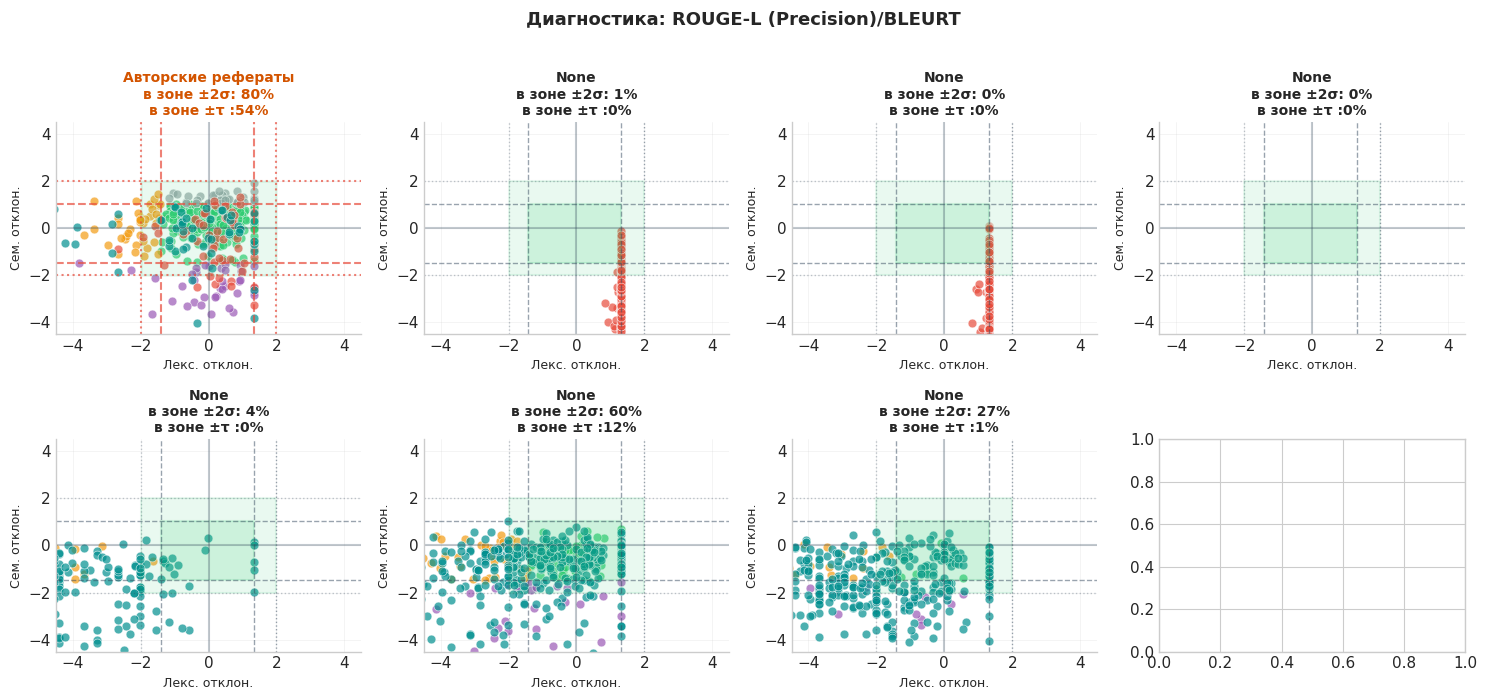

In [28]:
# 8.1.2 Сводный график (все модели на одном + эталонные АР)
print(f"\nСоздание сводного графика (режим порогов: {THRESHOLD_MODE})...")

models_list = df_final['model'].unique()

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

from matplotlib.patches import Rectangle

# Пороги из выбранного режима
tau_lex_upper = adaptive_thresholds['tau_lex_upper']
tau_lex_lower = adaptive_thresholds['tau_lex_lower']
tau_sem_upper = adaptive_thresholds['tau_sem_upper']
tau_sem_lower = adaptive_thresholds['tau_sem_lower']
tau_comp_upper = adaptive_thresholds['tau_comp_upper']
tau_comp_lower = adaptive_thresholds['tau_comp_lower']

# =============================================================================
# ПЕРВЫЙ SUBPLOT: Эталонные авторские рефераты (ОТ-АР)
# =============================================================================
ax_ref = axes[0]

# Получаем данные ОТ-АР и вычисляем z-scores
# df_ot_ar = df_raw[df_raw['comparison'] == 'OT-AR'].copy()
# df_ot_ar = df_ot_ar[~df_ot_ar['doc_id'].isin(calibration['outlier_doc_ids'])]

# df_ot_ar['z_lex'] = (df_ot_ar['lexical'] - calibration['mu_lex']) / calibration['sigma_lex']
# df_ot_ar['z_sem'] = (df_ot_ar['semantic'] - calibration['mu_sem']) / calibration['sigma_sem']

df_ot_ar = df_final_ref

DIAGNOSIS_COLORS = {
    'good': '#2ecc71',       # зеленый - хорошие рефераты
    'copying': '#3498db',    # красный - копирование
    'incomplete': '#9b59b6', # фиолетовый - неполнота
    'low_lexical': '#f39c12',# #3cd7e7 оранжевый - низкая лексика (новая категория)
    'ambiguous': '#95a5a6',  # серый - неоднозначные

    'under_compressed': '#e74c3c',
    'over_compressed': '#008f8f' # #f39c12 #e67e22
}
# LEX [-1.352, 1.370], SEM [-1.293, 1.268], COMP [-0.762, 1.466]

# Отрисовка точек АР
# ax_ref.scatter(df_ot_ar['z_lex'], df_ot_ar['z_sem'], 
#                c='#f1c40f', alpha=0.7, s=40, edgecolors='#d35400', linewidth=0.5,
#                label='Авторские рефераты')
for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_ot_ar[df_ot_ar['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        ax_ref.scatter(subset['z_lex'], subset['z_sem'], 
                    c=color, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)


# Оси
ax_ref.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)
ax_ref.axvline(x=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)

# Границы зон
ax_ref.axhline(y=tau_sem_lower, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax_ref.axhline(y=tau_sem_upper, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax_ref.axvline(x=tau_lex_lower, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
ax_ref.axvline(x=tau_lex_upper, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)

ax_ref.axhline(y=-2, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
ax_ref.axhline(y=2, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
ax_ref.axvline(x=-2, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
ax_ref.axvline(x=2, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)

# Целевая зона
width_good = tau_lex_upper - tau_lex_lower
height_good = tau_sem_upper - tau_sem_lower
good_zone = Rectangle((tau_lex_lower, tau_sem_lower), width_good, height_good, 
                      linewidth=2, edgecolor='#2ecc71', 
                      facecolor='#2ecc71', alpha=0.15)
good_zone = Rectangle((-2, -2), 4, 4, 
                      linewidth=2, edgecolor='#2ecc71', 
                      facecolor='#2ecc71', alpha=0.1)
ax_ref.add_patch(good_zone)

ax_ref.set_title('АВТОРСКИЕ РЕФЕРАТЫ', fontsize=11, fontweight='bold', pad=8, color='#d35400')
ax_ref.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Пределы для первого графика
margin = 0.5
# x_lim = max(abs(tau_lex_lower), abs(tau_lex_upper), 3) + margin
# y_lim = max(abs(tau_sem_lower), abs(tau_sem_upper), 3) + margin
# ax_ref.set_xlim(-x_lim, x_lim)
# ax_ref.set_ylim(-y_lim, y_lim)
ax_ref.set_xlim(-4-margin, 4+margin)
ax_ref.set_ylim(-4-margin, 4+margin)

ax_ref.spines['top'].set_visible(False)
ax_ref.spines['right'].set_visible(False)
ax_ref.set_xlabel('Лекс. отклон.', fontsize=9)
ax_ref.set_ylabel('Сем. отклон.', fontsize=9)

# Статистика для АР
good_ar_pct = 100 * len(df_ot_ar[df_ot_ar['diagnosis_type'] == 'good']) / len(df_ot_ar)
good_ar_tau = 100 * len(df_ot_ar[(df_ot_ar['z_lex'] >=  -2) & (df_ot_ar['z_lex'] <=  2) & 
                                 (df_ot_ar['z_sem'] >=  -2) & (df_ot_ar['z_sem'] <=  2) & 
                                 (df_ot_ar['z_comp'] >= -2) & (df_ot_ar['z_comp'] <= 2)]) / len(df_ot_ar)

# ax_ref.text(0.05, 0.95, f'n={len(df_ot_ar)}\nв зоне ±2σ: {pct_ar_good_tau:.0f}%\nв зоне ±τ: {pct_ar_good_ptc:.0f}%', 
#             transform=ax_ref.transAxes, fontsize=9, verticalalignment='top',
#             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

ax_ref.set_title(f'Авторские рефераты\nв зоне ±2σ: {good_ar_tau:.0f}%\nв зоне ±τ :{good_ar_pct:.0f}%', fontsize=10, fontweight='bold', pad=5)

# =============================================================================
# ОСТАЛЬНЫЕ SUBPLOTS: Модели суммаризации
# =============================================================================
for idx, model_name in enumerate(sorted(models_list)):
    ax = axes[idx+1]
    df_model = df_final[df_final['model'] == model_name]
    
    # Отрисовка точек
    for diag_type, color in DIAGNOSIS_COLORS.items():
        subset = df_model[df_model['diagnosis_type'] == diag_type]
        if len(subset) > 0:
            ax.scatter(subset['z_lex'], subset['z_sem'], 
                      c=color, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    # Оси
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)
    ax.axvline(x=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.3)
    
    # Границы зон
    ax.axhline(y=tau_sem_lower, color='#34495e', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=tau_sem_upper, color='#34495e', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=tau_lex_lower, color='#34495e', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=tau_lex_upper, color='#34495e', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.axhline(y=-2, color='#34495e', linestyle=':', linewidth=1, alpha=0.3)
    ax.axhline(y=2, color='#34495e', linestyle=':', linewidth=1, alpha=0.3)
    ax.axvline(x=-2, color='#34495e', linestyle=':', linewidth=1, alpha=0.3)
    ax.axvline(x=2, color='#34495e', linestyle=':', linewidth=1, alpha=0.5)
    
    # Целевая зона
    good_zone = Rectangle((tau_lex_lower, tau_sem_lower), width_good, height_good, 
                          linewidth=1.5, edgecolor='#2ecc71', 
                          facecolor='#2ecc71', alpha=0.15)
    ax.add_patch(good_zone)

    good_zone = Rectangle((-2, -2), 4, 4, 
                          linewidth=1.5, edgecolor='#2ecc71', 
                          facecolor='#2ecc71', alpha=0.1)
    ax.add_patch(good_zone)
    
    # Название модели + % в целевой зоне
    good_tau = 100 * len(df_model[(df_model['z_lex'] >=  -2) & (df_model['z_lex'] <=  2) & 
                                  (df_model['z_sem'] >=  -2) & (df_model['z_sem'] <=  2) & 
                                  (df_model['z_comp'] >= -2) & (df_model['z_comp'] <= 2)]) / len(df_model)
    good_pct = 100 * len(df_model[df_model['diagnosis_type'] == 'good']) / len(df_model) if len(df_model) > 0 else 0

    ax.set_title(f'{INTER_LABELS.get(model_name)}\nв зоне ±2σ: {good_tau:.0f}%\nв зоне ±τ :{good_pct:.0f}%', fontsize=10, fontweight='bold', pad=5)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Динамические пределы
    margin = 0.5
    # x_min = min(df_model['z_lex'].min(), tau_lex_lower) - margin
    # x_max = max(df_model['z_lex'].max(), tau_lex_upper) + margin
    # y_min = min(df_model['z_sem'].min(), tau_sem_lower) - margin
    # y_max = max(df_model['z_sem'].max(), tau_sem_upper) + margin

    # ax.set_xlim(x_min, x_max)
    # ax.set_ylim(y_min, y_max)

    if idx not in [1, 2]:
        ax.set_xlim(-4-margin, 4+margin)
        ax.set_ylim(-4-margin, 4+margin)

    if idx in [1, 2]:
        ax.set_xlim(-4-margin, 4+margin)
        # ax.set_ylim(-8-margin, 6+margin)
        ax.set_ylim(-4-margin, 4+margin)
    
    # else:
    #     ax.set_xlim(-1-margin, 13+margin)
    #     ax.set_ylim(-4-margin, 8+margin)
    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Подписи осей
    # if idx >= 3:
    # if idx % 4 == 3:
    ax.set_xlabel('Лекс. отклон.', fontsize=9)
    ax.set_ylabel('Сем. отклон.', fontsize=9)

plt.legend(loc='best')

# Заголовок с информацией о режиме
fig.suptitle(f'Диагностика: {LEX_NAME}/{SEM_NAME}', #  | Пороги: {THRESHOLD_MODE_LABEL}
             fontsize=13, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_diagnostic_scatter_for_all_models.png', dpi=600, bbox_inches='tight', facecolor='white')
print(f"✓ График сохранён: diagnostic_scatter_{THRESHOLD_MODE}.png")
print(f"  Режим порогов: {THRESHOLD_MODE_LABEL}")
print(f"  Пороги: LEX [{tau_lex_lower:.3f}, {tau_lex_upper:.3f}], SEM [{tau_sem_lower:.3f}, {tau_sem_upper:.3f}], COMP [{tau_comp_lower:.3f}, {tau_comp_upper:.3f}]")
print(f"  Авторские рефераты в целевой зоне:\n\tв зоне (±2σ): {good_ar_tau:.0f}%\n\tв зоне (±τ): {good_ar_pct:.1f}%")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Seq2Seq/tsm-figures/rougeL-vs-bleurt_quality_boxplot.png'

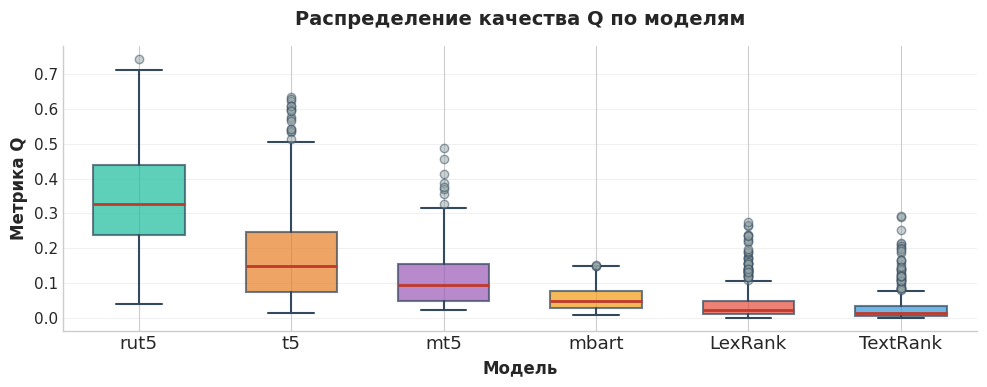

In [29]:
# 8.2 Box plots: Q по моделям
fig, ax = plt.subplots(figsize=(10, 4))

models_sorted = df_final.groupby('model')['Q'].median().sort_values(ascending=False).index
df_final['model_sorted'] = pd.Categorical(df_final['model'], categories=models_sorted, ordered=True)

# Создаём палитру цветов для моделей в порядке сортировки
model_palette = [MODEL_COLORS.get(m, '#95a5a6') for m in models_sorted]

bp = ax.boxplot([df_final[df_final['model'] == m]['Q'].values for m in models_sorted],
                labels=[m.replace('summary_', '') for m in models_sorted],
                patch_artist=True, widths=0.6,
                boxprops=dict(linewidth=1.5, edgecolor='#34495e'),
                whiskerprops=dict(linewidth=1.5, color='#34495e'),
                capprops=dict(linewidth=1.5, color='#34495e'),
                medianprops=dict(linewidth=2, color='#c0392b'),
                flierprops=dict(marker='o', markerfacecolor='#95a5a6', 
                               markersize=6, markeredgecolor='#34495e', alpha=0.5))

# Заливка box-ов цветами
for patch, color in zip(bp['boxes'], model_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Модель', fontsize=12, fontweight='bold')
ax.set_ylabel('Метрика Q', fontsize=12, fontweight='bold')
ax.set_title('Распределение качества Q по моделям', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=0,labelsize='large')
ax.grid(axis='y', alpha=0.4, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_quality_boxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ График 2 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/figures/{LEX_MODE}-vs-{SEM_MODE}_quality_boxplot.png")
plt.show()

✓ График 3 сохранён: tsm-reference-LLMs/correlation_heatmap_adaptive_tau.png


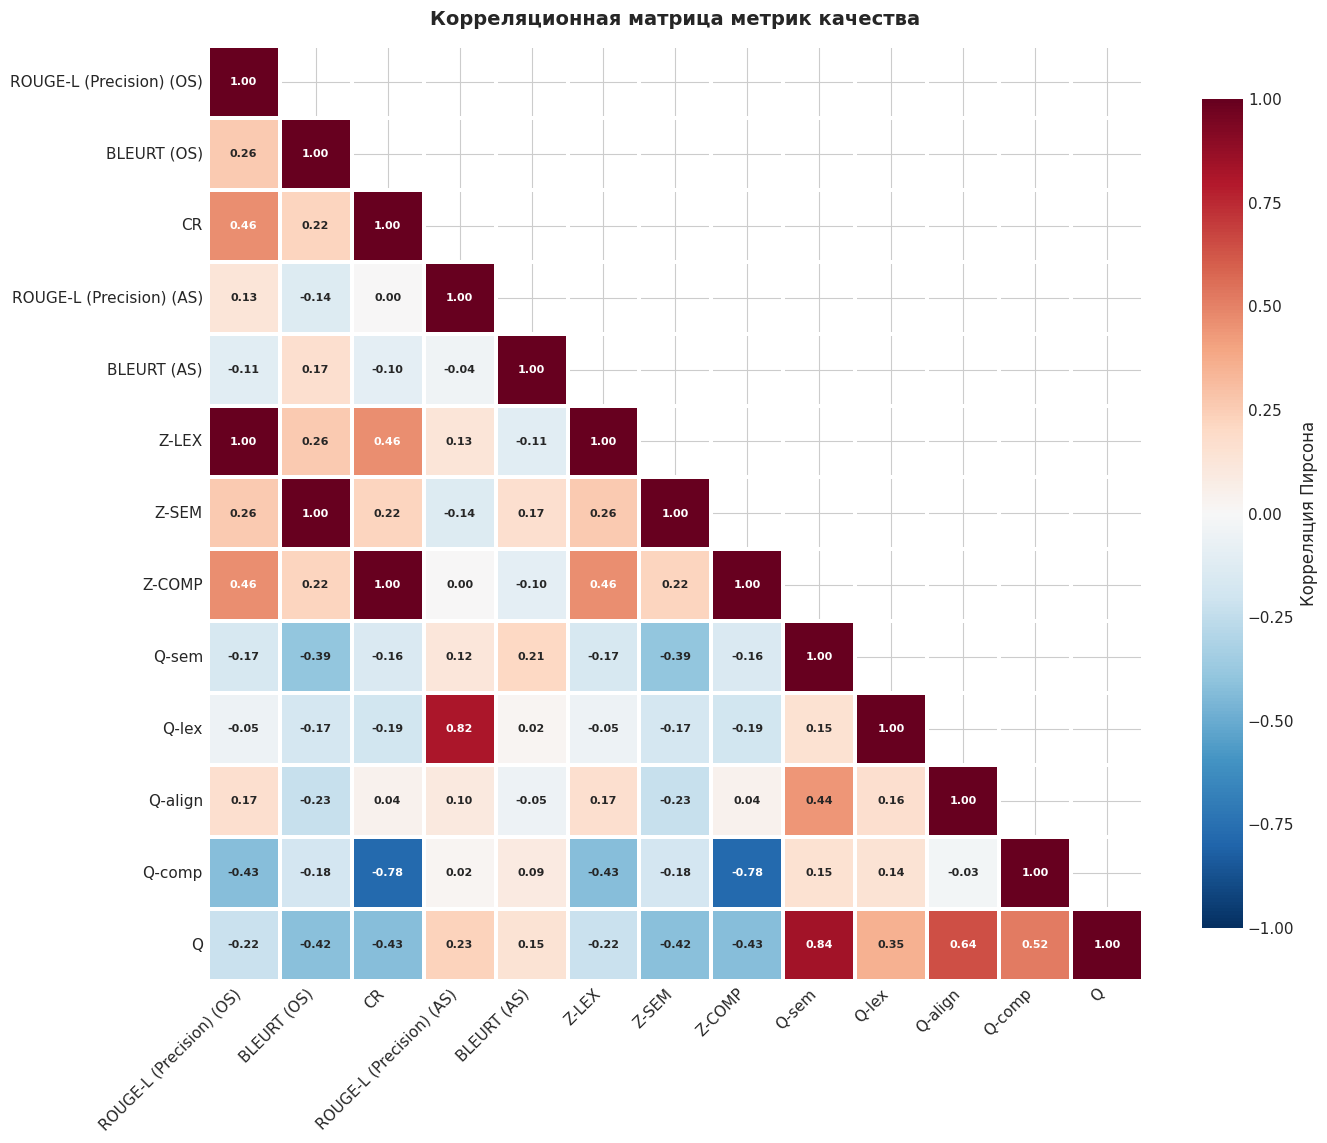

In [ ]:
# 8.3 Heatmap: корреляция всех метрик
has_comp_col = 'compression_ratio' in df_final.columns and df_final['compression_ratio'].notna().any()
has_q_comp = 'q_comp' in df_final.columns

base_cols = ['lexical_os', 'semantic_os']
base_labels = [f'{LEX_NAME} (OS)', f'{SEM_NAME} (OS)']

if has_comp_col:
    base_cols.append('compression_ratio')
    base_labels.append('CR')

base_cols += ['lexical_as', 'semantic_as', 'z_lex', 'z_sem']
base_labels += [f'{LEX_NAME} (AS)', f'{SEM_NAME} (AS)', 'Z-LEX', 'Z-SEM']

if has_comp_col:
    base_cols.append('z_comp')
    base_labels.append('Z-COMP')

base_cols += ['q_sem', 'q_lex', 'q_align']
base_labels += ['Q-sem', 'Q-lex', 'Q-align']

if has_q_comp:
    base_cols.append('q_comp')
    base_labels.append('Q-comp')

base_cols.append('Q')
base_labels.append('Q')

metrics_for_corr = df_final[base_cols]
corr_matrix = metrics_for_corr.corr()

corr_matrix.index = base_labels
corr_matrix.columns = base_labels

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=1.5,
            linecolor='white', cbar_kws={"shrink": 0.8, "label": "Корреляция Пирсона"},
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'fontsize': 8, 'fontweight': 'bold'})

ax.set_title('Корреляционная матрица метрик качества',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-correlation_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ График 3 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/correlation_heatmap_adaptive_tau.png")
plt.show()

In [ ]:
# df_df_final = df_final

In [ ]:
# df_df_final['lexical_chrf_os'] = df_final['lexical_os']
# df_df_final['lexical_chrf_as'] = df_final['lexical_as']

# df_df_final['lexical_rouge_f1_os'] = df_final['lexical_os']
# df_df_final['lexical_rouge_f1_as'] = df_final['lexical_as']

# df_df_final['lexical_rouge_p_os'] = df_final['lexical_os']
# df_df_final['lexical_rouge_p_as'] = df_final['lexical_as']

# df_df_final['semantic_bleurt_os'] = df_final['semantic_os']
# df_df_final['semantic_bleurt_as'] = df_final['semantic_as']

# 8.3 Heatmap: корреляция всех метрик
has_comp_col = 'compression_ratio' in df_df_final.columns and df_df_final['compression_ratio'].notna().any()
has_q_comp = 'q_comp' in df_df_final.columns

base_cols = [
    'lexical_chrf_os', 
    'lexical_rouge_f1_os',  
    'lexical_rouge_p_os',
    'semantic_os',
    'semantic_bleurt_os',
    'lexical_chrf_as',
    'lexical_rouge_f1_as',
    'lexical_rouge_p_as',
    'semantic_as',
    'semantic_bleurt_as'
    ]
# base_labels = [f'{LEX_NAME} (OS)', f'{SEM_NAME} (OS)']
base_labels = [
    f'chrF++ (OS)', 
    f'ROUGE-L (F1) (OS)', 
    f'ROUGE-L (Prec.) (OS)', 
    f'BERTScore (OS)',
    f'BLEURT (OS)',
    f'chrF++ (AS)', 
    f'ROUGE-L (F1) (AS)', 
    f'ROUGE-L (Prec.) (AS)', 
    f'BERTScore (AS)',
    f'BLEURT (AS)'
    ]

if has_comp_col:
    base_cols.append('compression_ratio')
    base_labels.append('Степень сжатия')

# base_cols += ['lexical_as', 'semantic_as']
# base_labels += [f'{LEX_NAME} (AS)', f'{SEM_NAME} (AS)']


metrics_for_corr = df_df_final[base_cols]
corr_matrix = metrics_for_corr.corr()

corr_matrix.index = base_labels
corr_matrix.columns = base_labels

fig, ax = plt.subplots(figsize=(8, 8))

# mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=1.5,
            linecolor='white', cbar_kws={"shrink": 0.7},
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'fontsize': 8, 'fontweight': 'bold'})

ax.set_title('Корреляционная матрица метрик качества',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'figures/{THRESHOLD_MODE}_RP_{LEX_MODE}-vs-{SEM_MODE}_correlation_heatmap_adaptive_tau.png', dpi=600, bbox_inches='tight', facecolor='white')
print("✓ График 3 сохранён: correlation_heatmap_adaptive_tau.png")
plt.show()

✓ График 4 сохранён: tsm-reference-LLMs/reference_distributions_adaptive_tau_rougeL-vs-bleurt.png


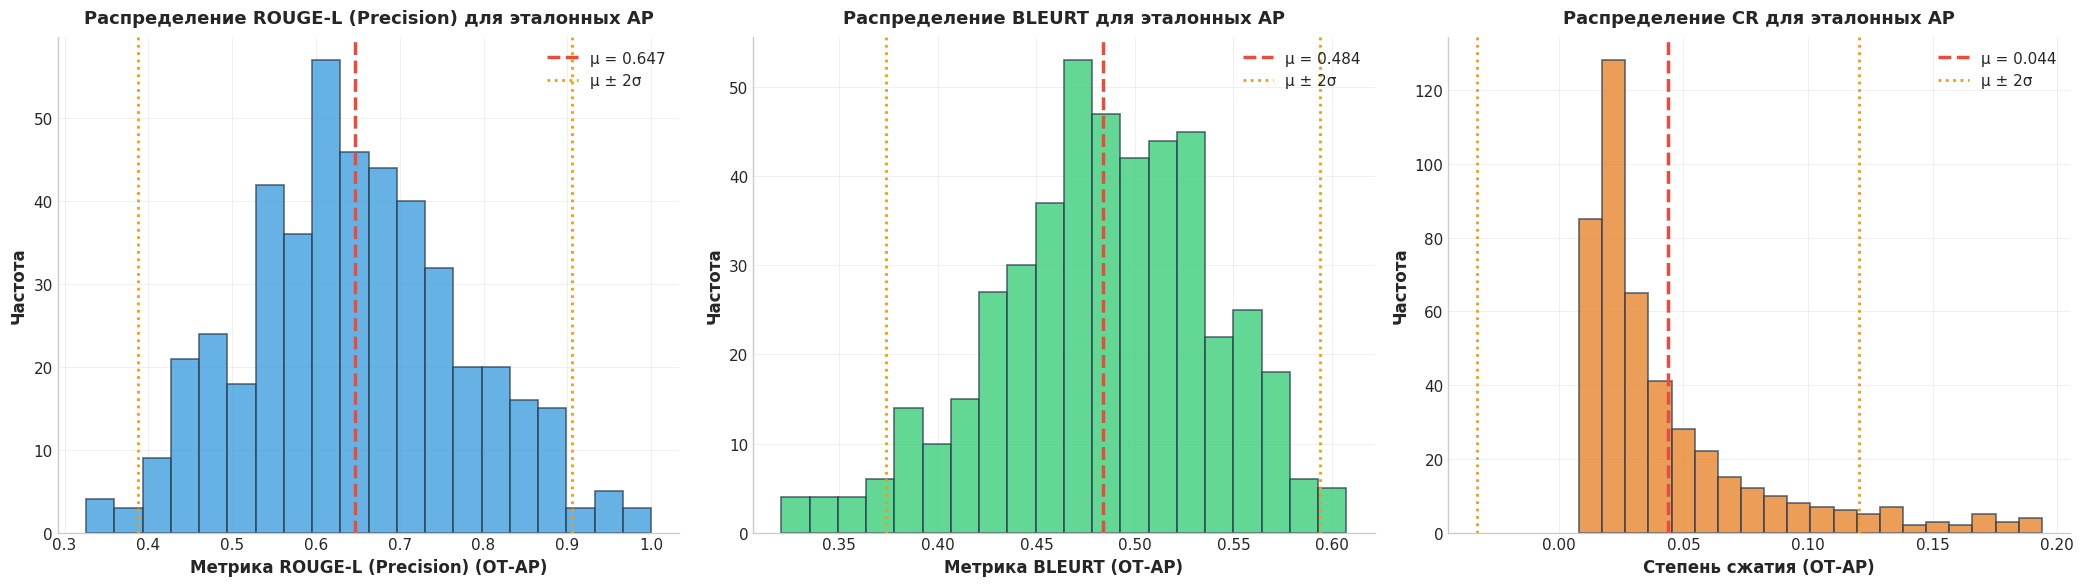

In [ ]:
# 8.4 Гистограммы распределений ОТ-АР (эталонных)

ot_ar_data = df_raw[df_raw['comparison'] == 'OT-AR']
ot_ar_clean = ot_ar_data[~ot_ar_data['doc_id'].isin(calibration['outlier_doc_ids'])]

has_comp_hist = 'compression_ratio' in ot_ar_clean.columns and ot_ar_clean['compression_ratio'].notna().any()
n_plots = 3 if has_comp_hist else 2

fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6))

# LEXICAL
axes[0].hist(ot_ar_clean['lexical'], bins=20, alpha=0.75,
             color='#3498db', edgecolor='#2c3e50', linewidth=1.2)
axes[0].axvline(calibration['mu_lex'], color='#e74c3c',
                linestyle='--', linewidth=2.5,
                label=f"μ = {calibration['mu_lex']:.3f}")
axes[0].axvline(calibration['mu_lex'] - 2*calibration['sigma_lex'],
                color='#f39c12', linestyle=':', linewidth=2, label='μ ± 2σ')
axes[0].axvline(calibration['mu_lex'] + 2*calibration['sigma_lex'],
                color='#f39c12', linestyle=':', linewidth=2)
axes[0].set_xlabel(f'Метрика {LEX_NAME} (ОТ-АР)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Частота', fontsize=12, fontweight='bold')
axes[0].set_title(f'Распределение {LEX_NAME} для эталонных АР',
                  fontsize=13, fontweight='bold', pad=10)
axes[0].legend(framealpha=0.95, edgecolor='gray', fancybox=True)
axes[0].grid(alpha=0.4, linestyle='-', linewidth=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# SEMANTIC
axes[1].hist(ot_ar_clean['semantic'], bins=20, alpha=0.75,
             color='#2ecc71', edgecolor='#2c3e50', linewidth=1.2)
axes[1].axvline(calibration['mu_sem'], color='#e74c3c',
                linestyle='--', linewidth=2.5,
                label=f"μ = {calibration['mu_sem']:.3f}")
axes[1].axvline(calibration['mu_sem'] - 2*calibration['sigma_sem'],
                color='#f39c12', linestyle=':', linewidth=2, label='μ ± 2σ')
axes[1].axvline(calibration['mu_sem'] + 2*calibration['sigma_sem'],
                color='#f39c12', linestyle=':', linewidth=2)
axes[1].set_xlabel(f'Метрика {SEM_NAME} (ОТ-АР)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Частота', fontsize=12, fontweight='bold')
axes[1].set_title(f'Распределение {SEM_NAME} для эталонных АР',
                  fontsize=13, fontweight='bold', pad=10)
axes[1].legend(framealpha=0.95, edgecolor='gray', fancybox=True)
axes[1].grid(alpha=0.4, linestyle='-', linewidth=0.5)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# COMPRESSION RATIO
if has_comp_hist:
    axes[2].hist(ot_ar_clean['compression_ratio'], bins=20, alpha=0.75,
                 color='#e67e22', edgecolor='#2c3e50', linewidth=1.2)
    axes[2].axvline(calibration['mu_comp'], color='#e74c3c',
                    linestyle='--', linewidth=2.5,
                    label=f"μ = {calibration['mu_comp']:.3f}")
    axes[2].axvline(calibration['mu_comp'] - 2*calibration['sigma_comp'],
                    color='#f39c12', linestyle=':', linewidth=2, label='μ ± 2σ')
    axes[2].axvline(calibration['mu_comp'] + 2*calibration['sigma_comp'],
                    color='#f39c12', linestyle=':', linewidth=2)
    axes[2].set_xlabel('Степень сжатия (ОТ-АР)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Частота', fontsize=12, fontweight='bold')
    axes[2].set_title('Распределение CR для эталонных АР',
                      fontsize=13, fontweight='bold', pad=10)
    axes[2].legend(framealpha=0.95, edgecolor='gray', fancybox=True)
    axes[2].grid(alpha=0.4, linestyle='-', linewidth=0.5)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_reference_distributions', dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ График 4 сохранён: tsm-{THRESHOLD_MODE}-{MODE}/reference_distributions_adaptive_tau_{LEX_MODE}-vs-{SEM_MODE}.png")
plt.show()

✓ График 5 сохранён: compression_ratio_boxplot.png


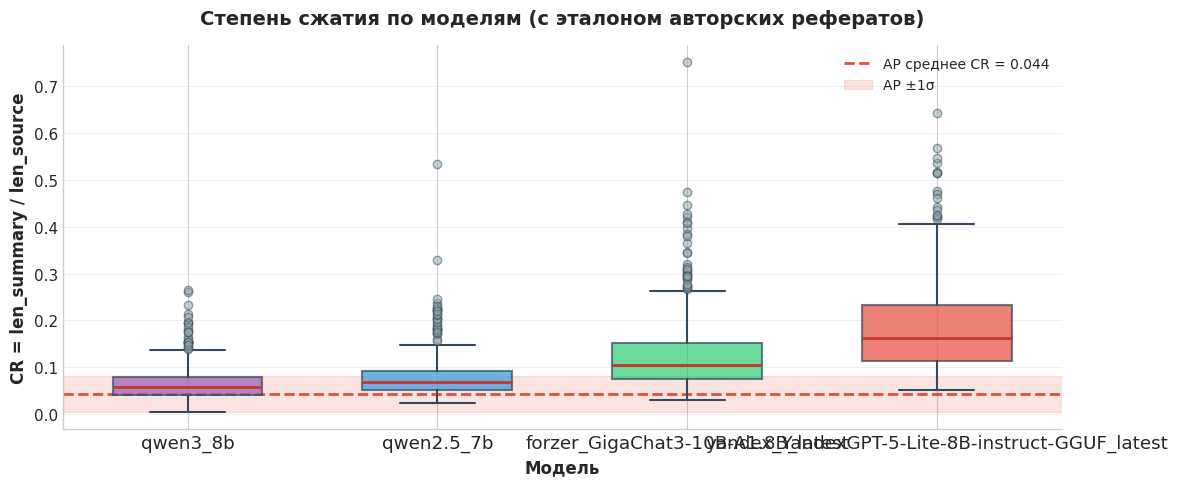

In [ ]:
# 8.5 Boxplot: Compression Ratio по моделям (с эталоном АР)

fig, ax = plt.subplots(figsize=(12, 5))

# Данные АР для эталонной линии
ar_cr = df_raw[df_raw['comparison'] == 'OT-AR']['compression_ratio']
ar_cr_clean = ar_cr[~df_raw[df_raw['comparison'] == 'OT-AR']['doc_id'].isin(calibration['outlier_doc_ids'])]

# Эталонная зона АР
ax.axhline(ar_cr_clean.mean(), color='#e74c3c', linestyle='--', linewidth=2,
           label=f'АР среднее CR = {ar_cr_clean.mean():.3f}')
ax.axhspan(ar_cr_clean.mean() - ar_cr_clean.std(), ar_cr_clean.mean() + ar_cr_clean.std(),
           alpha=0.15, color='#e74c3c', label=f'АР ±1σ')

# Boxplots моделей
models_sorted = df_final.groupby('model')['compression_ratio'].median().sort_values().index
bp = ax.boxplot(
    [df_final[df_final['model'] == m]['compression_ratio'].values for m in models_sorted],
    labels=[m.replace('summary_', '') for m in models_sorted],
    patch_artist=True, widths=0.6,
    boxprops=dict(linewidth=1.5, edgecolor='#34495e'),
    whiskerprops=dict(linewidth=1.5, color='#34495e'),
    capprops=dict(linewidth=1.5, color='#34495e'),
    medianprops=dict(linewidth=2, color='#c0392b'),
    flierprops=dict(marker='o', markerfacecolor='#95a5a6', markersize=6,
                    markeredgecolor='#34495e', alpha=0.5)
)

model_palette = [MODEL_COLORS.get(m, '#95a5a6') for m in models_sorted]
for patch, color in zip(bp['boxes'], model_palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Модель', fontsize=12, fontweight='bold')
ax.set_ylabel('CR = len_summary / len_source', fontsize=12, fontweight='bold')
ax.set_title('Степень сжатия по моделям (с эталоном авторских рефератов)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=0, labelsize='large')
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax.grid(axis='y', alpha=0.4, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_compression_ratio_boxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ График 5 сохранён: compression_ratio_boxplot.png")
plt.show()

✓ График 6 сохранён: compression_scatter_z.png


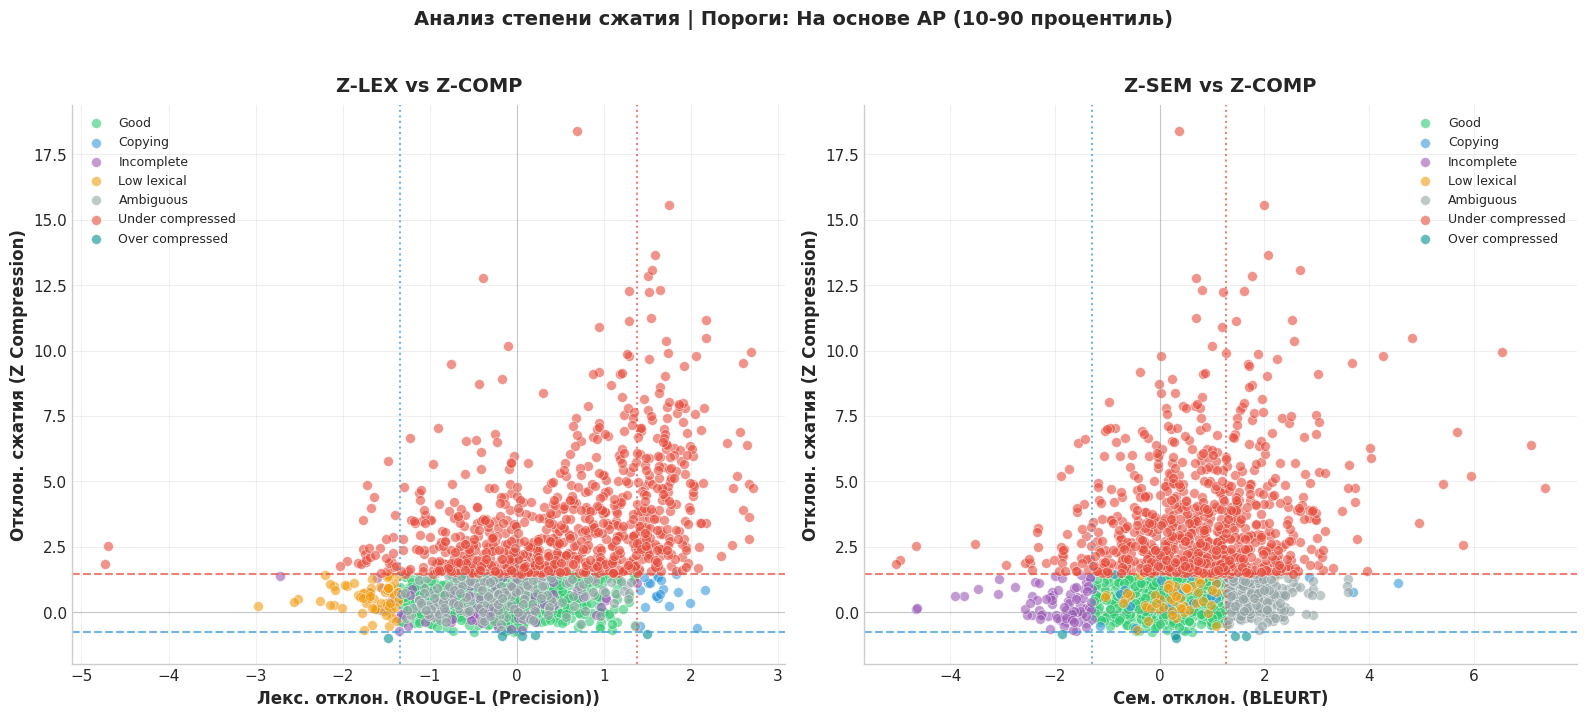

In [ ]:
# 8.6 Scatter: z_comp vs z_lex и z_comp vs z_sem

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

tau_comp_upper = adaptive_thresholds.get('tau_comp_upper', 2.0)
tau_comp_lower = adaptive_thresholds.get('tau_comp_lower', -2.0)
tau_lex_upper = adaptive_thresholds.get('tau_lex_upper')
tau_lex_lower = adaptive_thresholds.get('tau_lex_lower')
tau_sem_upper = adaptive_thresholds.get('tau_sem_upper')
tau_sem_lower = adaptive_thresholds.get('tau_sem_lower')

# z_lex vs z_comp
for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        axes[0].scatter(subset['z_lex'], subset['z_comp'], c=color,
                       label=diag_type.replace('_', ' ').capitalize(), alpha=0.6, s=50,
                       edgecolors='white', linewidth=0.5)

axes[0].axhline(y=tau_comp_upper, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].axhline(y=tau_comp_lower, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].axvline(x=tau_lex_upper, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].axvline(x=tau_lex_lower, color='#3498db', linestyle=':', linewidth=1.5, alpha=0.7)
axes[0].axhline(y=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)
axes[0].axvline(x=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)

axes[0].set_xlabel(f'Лекс. отклон. ({LEX_NAME})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Отклон. сжатия (Z Compression)', fontsize=12, fontweight='bold')
axes[0].set_title('Z-LEX vs Z-COMP', fontsize=14, fontweight='bold', pad=10)
axes[0].legend(loc='best', fontsize=9, framealpha=0.95)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# z_sem vs z_comp
for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        axes[1].scatter(subset['z_sem'], subset['z_comp'], c=color,
                       label=diag_type.replace('_', ' ').capitalize(), alpha=0.6, s=50,
                       edgecolors='white', linewidth=0.5)

axes[1].axhline(y=tau_comp_upper, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axhline(y=tau_comp_lower, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].axvline(x=tau_sem_upper, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1].axvline(x=tau_sem_lower, color='#3498db', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1].axhline(y=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)
axes[1].axvline(x=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)

axes[1].set_xlabel(f'Сем. отклон. ({SEM_NAME})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Отклон. сжатия (Z Compression)', fontsize=12, fontweight='bold')
axes[1].set_title('Z-SEM vs Z-COMP', fontsize=14, fontweight='bold', pad=10)
axes[1].legend(loc='best', fontsize=9, framealpha=0.95)
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(f'Анализ степени сжатия | Пороги: {THRESHOLD_MODE_LABEL}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures-{S2S_SET}/{LEX_MODE}-vs-{SEM_MODE}_compression_scatter_z.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ График 6 сохранён: compression_scatter_z.png")
plt.show()

✓ График 7 сохранён: compression_vs_quality.png


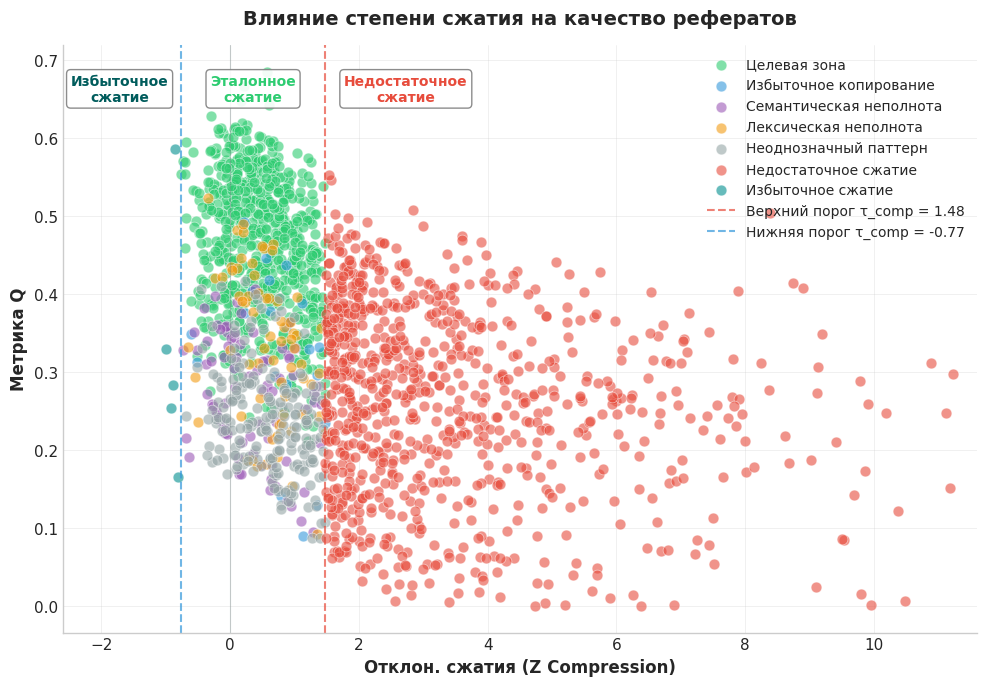

In [ ]:
# 8.7 Scatter: z_comp vs Q (влияние компрессии на качество)

fig, ax = plt.subplots(figsize=(10, 7))

DIAG_TRANSLATE = {
    'good': 'Целевая зона',
    'copying': 'Избыточное копирование',
    'incomplete': 'Семантическая неполнота',
    'low_lexical': 'Лексическая неполнота',
    'ambiguous': 'Неоднозначный паттерн',

    'under_compressed': 'Недостаточное сжатие',
    'over_compressed': 'Избыточное сжатие'
}

for diag_type, color in DIAGNOSIS_COLORS.items():
    subset = df_final[df_final['diagnosis_type'] == diag_type]
    if len(subset) > 0:
        ax.scatter(subset['z_comp'], subset['Q'], c=color,
                #   label=diag_type.replace('_', ' ').capitalize(),
                  label=DIAG_TRANSLATE.get(diag_type), #diag_type.capitalize().replace('_', ' '), 
                  alpha=0.6, s=60, edgecolors='white', linewidth=0.5)

# Пороги компрессии
tau_comp_upper = adaptive_thresholds.get('tau_comp_upper', 2.0)
tau_comp_lower = adaptive_thresholds.get('tau_comp_lower', -2.0)
ax.axvline(x=tau_comp_upper, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Верхний порог τ_comp = {tau_comp_upper:.2f}')
ax.axvline(x=tau_comp_lower, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Нижняя порог τ_comp = {tau_comp_lower:.2f}')
ax.axvline(x=0, color='#7f8c8d', linestyle='-', linewidth=0.8, alpha=0.4)

ax.set_xlabel('Отклон. сжатия (Z Compression)', fontsize=12, fontweight='bold')
ax.set_ylabel('Метрика Q', fontsize=12, fontweight='bold')
ax.set_title('Влияние степени сжатия на качество рефератов', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='gray', fancybox=True)
ax.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Аннотации зон

center_x = (tau_comp_upper+tau_comp_lower)/2

bbox_style = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9)
ax.text(tau_comp_lower - 0.95, ax.get_ylim()[1] * 0.9, 'Избыточное\nсжатие',
        ha='center', fontsize=10, fontweight='bold', bbox=bbox_style, color='#005c5c')
ax.text(tau_comp_upper + 1.25, ax.get_ylim()[1] * 0.9, 'Недостаточное\nсжатие',
        ha='center', fontsize=10, fontweight='bold', bbox=bbox_style, color='#e74c3c')
ax.text(center_x, ax.get_ylim()[1] * 0.9, 'Эталонное\nсжатие',
        ha='center', fontsize=10, fontweight='bold', bbox=bbox_style, color='#2ecc71')

ax.set_xlim((-2.6,11.6))

plt.tight_layout()
plt.savefig(f'{MODE}/tsm-figures/{LEX_MODE}-vs-{SEM_MODE}_compression_vs_quality.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ График 7 сохранён: compression_vs_quality.png")
plt.show()

In [ ]:
# =============================================================================
# 9. ПОДГОТОВКА ДАННЫХ ДЛЯ ЭКСПЕРТНОЙ ВАЛИДАЦИИ
# =============================================================================

print("\n" + "="*70)
print("ЭТАП 6: ПОДГОТОВКА К ЭКСПЕРТНОЙ ВАЛИДАЦИИ")
print("="*70)

# Выбираем репрезентативную выборку для экспертов
# Стратегия: по 10 документов каждого типа диагноза

def prepare_expert_sample(df_final: pd.DataFrame, 
                          n_per_diagnosis: int = 10,
                          random_state: int = 42) -> pd.DataFrame:
    """
    Формирует сбалансированную выборку для экспертной оценки.
    """
    samples = []
    
    for diag_type in ['good', 'copying', 'incomplete', 'ambiguous']:
        subset = df_final[df_final['diagnosis_type'] == diag_type]
        if len(subset) >= n_per_diagnosis:
            sample = subset.sample(n=n_per_diagnosis, random_state=random_state)
        else:
            sample = subset
        samples.append(sample)
    
    expert_sample = pd.concat(samples, ignore_index=True)
    
    # Добавляем столбцы для экспертных оценок
    expert_sample['expert1_factuality'] = np.nan
    expert_sample['expert1_coverage'] = np.nan
    expert_sample['expert1_conciseness'] = np.nan
    expert_sample['expert1_coherence'] = np.nan
    
    expert_sample['expert2_factuality'] = np.nan
    expert_sample['expert2_coverage'] = np.nan
    expert_sample['expert2_conciseness'] = np.nan
    expert_sample['expert2_coherence'] = np.nan
    
    expert_sample['expert3_factuality'] = np.nan
    expert_sample['expert3_coverage'] = np.nan
    expert_sample['expert3_conciseness'] = np.nan
    expert_sample['expert3_coherence'] = np.nan
    
    return expert_sample

expert_data = prepare_expert_sample(df_final, n_per_diagnosis=10)

print(f"\nСформирована выборка для экспертов:")
print(f"  Всего документов: {len(expert_data)}")
print(f"  Распределение по типам:")
print(expert_data['diagnosis_type'].value_counts())

# Сохраняем для экспертов
expert_data_export = expert_data[['doc_id', 'model', 'diagnosis_type', 'Q',
                                   'lexical_os', 'semantic_os', 'z_lex', 'z_sem',
                                   'expert1_factuality', 'expert1_coverage', 
                                   'expert1_conciseness', 'expert1_coherence',
                                   'expert2_factuality', 'expert2_coverage',
                                   'expert2_conciseness', 'expert2_coherence',
                                   'expert3_factuality', 'expert3_coverage',
                                   'expert3_conciseness', 'expert3_coherence']]

expert_data_export.to_csv(f'{MODE}/tsm-{THRESHOLD_MODE}-expert_validation_template.csv', index=False, encoding='utf-8')
print(f"\n✓ Файл для экспертной оценки сохранён: expert_validation_template.csv")
print(f"\nИнструкция для экспертов:")
print(f"  1. Оцените каждый реферат по 4 критериям (шкала 1-5)")
print(f"  2. Factuality: точность фактов (1=много ошибок, 5=точен)")
print(f"  3. Coverage: полнота (1=упущены ключевые моменты, 5=все важное)")
print(f"  4. Conciseness: краткость (1=многословен, 5=оптимален)")
print(f"  5. Coherence: связность (1=хаотичен, 5=логичен)")


ЭТАП 6: ПОДГОТОВКА К ЭКСПЕРТНОЙ ВАЛИДАЦИИ

Сформирована выборка для экспертов:
  Всего документов: 40
  Распределение по типам:
diagnosis_type
good          10
copying       10
incomplete    10
ambiguous     10
Name: count, dtype: int64

✓ Файл для экспертной оценки сохранён: expert_validation_template.csv

Инструкция для экспертов:
  1. Оцените каждый реферат по 4 критериям (шкала 1-5)
  2. Factuality: точность фактов (1=много ошибок, 5=точен)
  3. Coverage: полнота (1=упущены ключевые моменты, 5=все важное)
  4. Conciseness: краткость (1=многословен, 5=оптимален)
  5. Coherence: связность (1=хаотичен, 5=логичен)


In [ ]:
# =============================================================================
# 10. ИТОГОВАЯ СВОДКА
# =============================================================================

print("\n" + "="*70)
print("ИТОГОВАЯ СВОДКА АНАЛИЗА")
print("="*70)

print(f"\n📊 СТАТИСТИКА КОРПУСА:")
print(f"   Всего документов: {len(df_raw['doc_id'].unique())}")
print(f"   Моделей суммаризации: {len(df_final['model'].unique())}")
print(f"   Аномальных АР удалено: {len(calibration['outlier_doc_ids'])}")

print(f"\n📏 ЭТАЛОННЫЕ ПАРАМЕТРЫ (ОТ-АР, очищенные):")
print(f"   LEXICAL:      μ = {calibration['mu_lex']:.4f} ± {calibration['sigma_lex']:.4f}")
print(f"   SEMANTIC:     μ = {calibration['mu_sem']:.4f} ± {calibration['sigma_sem']:.4f}")
if 'mu_comp' in calibration:
    print(f"   COMPRESSION:  μ = {calibration['mu_comp']:.4f} ± {calibration['sigma_comp']:.4f}")

print(f"\n🎯 ПОРОГИ (режим: {THRESHOLD_MODE_LABEL}):")
print(f"   LEXICAL:      [{adaptive_thresholds['tau_lex_lower']:.3f}, {adaptive_thresholds['tau_lex_upper']:.3f}]")
print(f"   SEMANTIC:     [{adaptive_thresholds['tau_sem_lower']:.3f}, {adaptive_thresholds['tau_sem_upper']:.3f}]")
if 'tau_comp_lower' in adaptive_thresholds:
    print(f"   COMPRESSION:  [{adaptive_thresholds['tau_comp_lower']:.3f}, {adaptive_thresholds['tau_comp_upper']:.3f}]")
try:
    print(f"   Корреляция:   ρ = {adaptive_thresholds['correlation']:.3f}")
except:
    print(f"   Корреляция:   ---")

print(f"\n🎯 ДИАГНОСТИКА МАШИННЫХ РЕФЕРАТОВ:")
diagnosis_stats = df_final['diagnosis_type'].value_counts()
for dtype, count in diagnosis_stats.items():
    pct = 100 * count / len(df_final)
    print(f"   {dtype:20s}: {count:4d} ({pct:5.1f}%)")

print(f"\n🏆 ТОП-3 МОДЕЛИ ПО МЕТРИКЕ Q:")
top_models = df_final.groupby('model')['Q'].mean().sort_values(ascending=False)
for rank, (model, q_score) in enumerate(top_models.head(3).items(), 1):
    print(f"   {rank}. {model:20s}: Q = {q_score:.4f}")

print(f"\n📐 ФОРМУЛА КАЧЕСТВА:")
print(f"   Q = 0.45·q_sem + 0.25·q_lex + 0.15·q_align + 0.15·q_comp")
print(f"   q_comp = exp(-(z_comp)²/2) — штраф за отклонение сжатия от авторского")


ИТОГОВАЯ СВОДКА АНАЛИЗА

📊 СТАТИСТИКА КОРПУСА:
   Всего документов: 472
   Моделей суммаризации: 4
   Аномальных АР удалено: 14

📏 ЭТАЛОННЫЕ ПАРАМЕТРЫ (ОТ-АР, очищенные):
   LEXICAL:      μ = 0.6465 ± 0.1297
   SEMANTIC:     μ = 0.4837 ± 0.0550
   COMPRESSION:  μ = 0.0438 ± 0.0384

🎯 ПОРОГИ (режим: На основе АР (10-90 процентиль)):
   LEXICAL:      [-1.348, 1.373]
   SEMANTIC:     [-1.289, 1.271]
   COMPRESSION:  [-0.766, 1.479]
   Корреляция:   ρ = 0.130

🎯 ДИАГНОСТИКА МАШИННЫХ РЕФЕРАТОВ:
   under_compressed    :  828 ( 43.9%)
   good                :  687 ( 36.4%)
   ambiguous           :  200 ( 10.6%)
   incomplete          :   79 (  4.2%)
   low_lexical         :   69 (  3.7%)
   copying             :   20 (  1.1%)
   over_compressed     :    5 (  0.3%)

🏆 ТОП-3 МОДЕЛИ ПО МЕТРИКЕ Q:
   1. summary_qwen2.5_7b  : Q = 0.3903
   2. summary_qwen3_8b    : Q = 0.3779
   3. summary_forzer_GigaChat3-10B-A1.8B_latest: Q = 0.3258

📐 ФОРМУЛА КАЧЕСТВА:
   Q = 0.45·q_sem + 0.25·q_lex + 0.15·q_al

In [ ]:
# =============================================================================
# 11. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ (ОПЦИОНАЛЬНО)
# =============================================================================

# 11.1 Сравнение с baseline метриками
print("\n" + "="*70)
print("БОНУС: СРАВНЕНИЕ С BASELINE МЕТРИКАМИ")
print("="*70)

print("\nКорреляция Q с базовыми метриками (AR-SR):")
print(f"  Q vs LEXICAL (AR-SR):     r = {df_final['Q'].corr(df_final['lexical_as']):.4f}")
print(f"  Q vs SEMANTIC (AR-SR):    r = {df_final['Q'].corr(df_final['semantic_as']):.4f}")
if 'compression_ratio' in df_final.columns:
    print(f"  Q vs COMPRESSION RATIO:   r = {df_final['Q'].corr(df_final['compression_ratio']):.4f}")
if 'q_comp' in df_final.columns:
    print(f"  Q vs Q-COMP:              r = {df_final['Q'].corr(df_final['q_comp']):.4f}")

print("\nОжидаемые результаты после экспертной валидации:")
print("  Q vs Expert:       r ~ 0.65-0.75 (целевой показатель)")
print("  LEXICAL vs Expert: r ~ 0.35 (из литературы)")
print("  SEMANTIC vs Expert: r ~ 0.42 (из литературы)")

# 11.2 Экспорт полных результатов
export_cols = ['doc_id', 'model', 'diagnosis_type',
               'lexical_os', 'semantic_os']

if 'compression_ratio' in df_final.columns:
    export_cols.append('compression_ratio')

export_cols += ['lexical_as', 'semantic_as', 'z_lex', 'z_sem']

if 'z_comp' in df_final.columns:
    export_cols.append('z_comp')

export_cols += ['q_sem', 'q_lex', 'q_align']

if 'q_comp' in df_final.columns:
    export_cols.append('q_comp')

export_cols += ['Q', 'diagnosis_confidence']

df_final_export = df_final[export_cols]
df_final_export.to_csv(f'{MODE}/tsm-{THRESHOLD_MODE}-full_analysis_results.csv', index=False, encoding='utf-8')
print(f"\n✓ Полные результаты сохранены: {MODE}/tsm-{THRESHOLD_MODE}-full_analysis_results.csv ({len(export_cols)} столбцов)")

print("\n🎓 Notebook завершён. Готово к использованию в диссертации!")


БОНУС: СРАВНЕНИЕ С BASELINE МЕТРИКАМИ

Корреляция Q с базовыми метриками (AR-SR):
  Q vs LEXICAL (AR-SR):     r = 0.2321
  Q vs SEMANTIC (AR-SR):    r = 0.1460
  Q vs COMPRESSION RATIO:   r = -0.4278
  Q vs Q-COMP:              r = 0.5203

Ожидаемые результаты после экспертной валидации:
  Q vs Expert:       r ~ 0.65-0.75 (целевой показатель)
  LEXICAL vs Expert: r ~ 0.35 (из литературы)
  SEMANTIC vs Expert: r ~ 0.42 (из литературы)

✓ Полные результаты сохранены: LLMs/tsm-reference-full_analysis_results.csv (17 столбцов)

🎓 Notebook завершён. Готово к использованию в диссертации!
